In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.colorbar import Colorbar
from matplotlib import colors
from scipy import special
from scipy.stats import linregress
from scipy.optimize import curve_fit
from mycolorpy import colorlist as mcp
from pathlib import Path
import pandas as pd
import matplotlib as mpl
import glob 
import os
import h5py


plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{xcolor}"
plt.rcParams["font.family"] = "lmodern"

In [6]:
cwd = Path().resolve()
project_root = cwd.parent

data_equilibrium_dir = project_root / "data" / "equilibrium"
data_quench_dir = project_root / "data" / "quench" / "quench_paper"
plot_dir = project_root / "plot"/"figures"/"figures_paper"
checkpoint_dir = project_root / "checkpoints" / "quench" / "quench_paper"

In [5]:
def scan_fit_window(l_smooth, F_smooth, N_sites, l_min_range=range(10, 100, 5), l_max=180):
    results = []
    for lmin in l_min_range:
        mask = (l_smooth >= lmin) & (l_smooth < l_max)
        if mask.sum() < 10:
            continue
        d_l = (2 * N_sites / np.pi) * np.sin(np.pi * l_smooth[mask] / N_sites)
        slope, intercept, r, p, se = linregress(np.log(d_l), F_smooth[mask])
        results.append((lmin, slope * 2 * np.pi**2, se * 2 * np.pi**2))
    return pd.DataFrame(results, columns=["l_min", "K_fit", "K_err"])


def extract_LL_parameter_from_NNN_simulation_V00_OBC():
    df = pd.read_csv(project_root / "data/fluctuations/quench_paper/bipartite_fluctuations_post_quench_N400_l4-200_V00.csv")
    N_sites = 400

    l_raw = df['length_sub'].values
    F_raw = df['Variance'].values

    # --- 3. Apply 4-Site Moving Average ---
    window = 4
    F_smooth = np.convolve(F_raw, np.ones(window) / window, mode='valid')
    l_smooth = l_raw[0:len(F_smooth)] + (window - 1) / 2.0

    # --- 3b. Scan the fit window BEFORE committing to one ---
    scan_df = scan_fit_window(l_smooth, F_smooth, N_sites, l_min_range=range(10, 100, 5), l_max=180)
    print(scan_df.to_string(index=False))

    # Optional: quick visual of the plateau
    plt.figure(figsize=(6, 4))
    plt.errorbar(scan_df['l_min'], scan_df['K_fit'], yerr=scan_df['K_err'], fmt='o-')
    plt.axhline(1.0, color='gray', linestyle=':', label='Exact K=1 (free fermion)')
    plt.xlabel(r'$l_{\min}$ cutoff')
    plt.ylabel(r'$K_{fit}$')
    plt.legend()
    plt.title('K stability vs. fit window')
    plt.tight_layout()
    plt.show()

    # --- 4. Conformal Distance Mapping ---
    d_l = (2 * N_sites / np.pi) * np.sin(np.pi * l_smooth / N_sites)
    ln_d_l = np.log(d_l)

    # --- 5. Linear Fit (now informed by the scan above, not hand-picked) ---
    fit_mask = (l_smooth >= 40) & (l_smooth < 90)
    ln_d_l_fit = ln_d_l[fit_mask]
    F_fit = F_smooth[fit_mask]

    slope, intercept, r_value, p_value, std_err = linregress(ln_d_l_fit, F_fit)
    K_extracted = slope * (2 * np.pi ** 2)

    print("=" * 50)
    print(f"Linear Fit Results (l >= 40 and l < 90):")
    print(f"Slope (m) = {slope:.6f}")
    print(f"R-squared = {r_value**2:.6f}")
    print(f"Extracted Luttinger Parameter K = {K_extracted:.6f}")
    print("=" * 50)

    # ... rest of your plotting code unchanged ...

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

    # Plot 1: F vs l (Linear scale, showing raw vs smoothed)
    ax1.plot(l_raw, F_raw, color='lightgray', marker='o', markersize=3, linestyle='-', label="Raw Data (Period-4 Oscillations)")
    ax1.plot(l_smooth, F_smooth, color='red', linewidth=2, label="4-Site Moving Average")
    ax1.set_xlabel(r"Subsystem Length $l$", fontsize=20)
    ax1.set_ylabel(r"Charge Variance $\mathcal{F}(l)$", fontsize=20)
    ax1.set_title("Bipartite Charge Fluctuations", fontsize=20)
    ax1.legend(fontsize=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.tick_params(axis='both', which='major', labelsize=16)

    # Plot 2: F vs ln(d(l)) (Log scale mapping, showing the linear fit)
    ax2.plot(ln_d_l, F_smooth, color='red', marker='o', markersize=4, linestyle='', label="Smoothed Data")
    # Plot the fit line
    x_fit_line = np.linspace(min(ln_d_l_fit), max(ln_d_l_fit), 100)
    y_fit_line = slope * x_fit_line + intercept
    ax2.plot(x_fit_line, y_fit_line, color='black', linestyle='--', linewidth=2, 
    label=f"Linear Fit\n$m = {slope:.4f}$\n$K = {K_extracted:.4f}$")

    ax2.set_xlabel(r"Conformal Distance $\ln \left[ \frac{N}{\pi} \sin\left(\frac{\pi l}{N}\right) \right]$", fontsize=20)
    ax2.set_ylabel(r"Smoothed Variance $\mathcal{F}$", fontsize=20)
    ax2.set_title(r"Extracting Luttinger Parameter $K$", fontsize=20)
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.legend(fontsize=20)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    plt.savefig(plot_dir / "extract_LL_parameter_from_NNN_simulation_V05_N400_t200.pdf", dpi=300)
    plt.show()



 l_min    K_fit    K_err
    10 0.972249 0.000424
    15 0.973988 0.000341
    20 0.974313 0.000366
    25 0.974405 0.000407
    30 0.973957 0.000451
    35 0.973437 0.000500
    40 0.972585 0.000544
    45 0.971694 0.000592
    50 0.970544 0.000634
    55 0.969354 0.000683
    60 0.967927 0.000724
    65 0.966450 0.000771
    70 0.964742 0.000811
    75 0.962980 0.000859
    80 0.960981 0.000898
    85 0.958911 0.000945
    90 0.956586 0.000983
    95 0.954186 0.001029


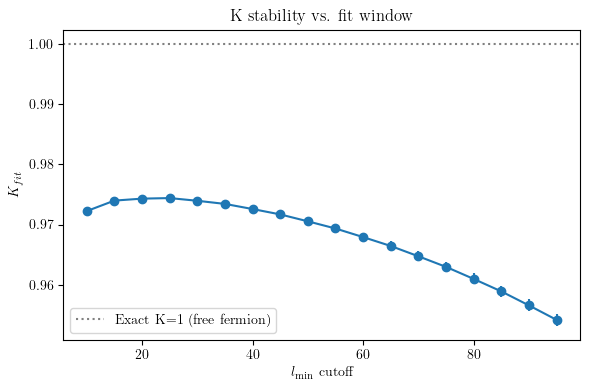

Linear Fit Results (l >= 40 and l < 90):
Slope (m) = 0.049641
R-squared = 0.999993
Extracted Luttinger Parameter K = 0.979874


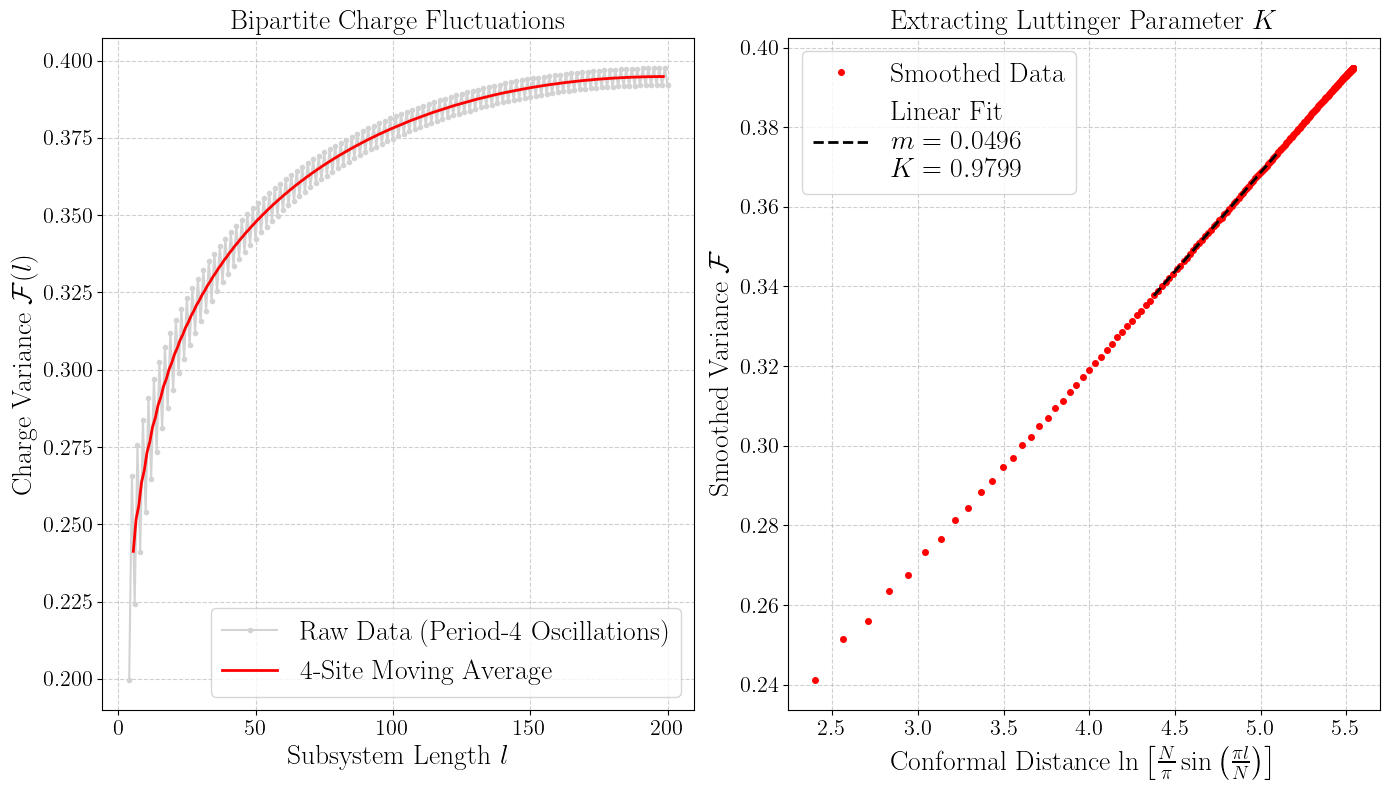

In [6]:
extract_LL_parameter_from_NNN_simulation_V00_OBC()

In [9]:
def scan_fit_window(l_smooth, F_smooth, N_sites, l_min_range=range(10, 100, 5), l_max=180):
    results = []
    for lmin in l_min_range:
        mask = (l_smooth >= lmin) & (l_smooth < l_max)
        if mask.sum() < 10:
            continue
        d_l = (2 * N_sites / np.pi) * np.sin(np.pi * l_smooth[mask] / N_sites)
        slope, intercept, r, p, se = linregress(np.log(d_l), F_smooth[mask])
        results.append((lmin, slope * 2 * np.pi**2, se * 2 * np.pi**2))
    return pd.DataFrame(results, columns=["l_min", "K_fit", "K_err"])


def extract_LL_parameter_from_NNN_simulation_V05_BA():
    df = pd.read_csv(project_root / "data/fluctuations/quench_paper/bipartite_fluctuations_post_quench_N400_l4-200_V05_BA.csv")
    N_sites = 400

    l_raw = df['length_sub'].values
    F_raw = df['Variance'].values

    # --- Theory for computing Bethe Ansatz predictions for K (if needed) ---
    V_param = 0.5
    mu = np.arccos(V_param / 2)
    K_BA = np.pi / (2 * (np.pi - mu))

    # --- 3. Apply 4-Site Moving Average ---
    window = 4
    F_smooth = np.convolve(F_raw, np.ones(window) / window, mode='valid')
    l_smooth = l_raw[0:len(F_smooth)] + (window - 1) / 2.0

    # --- 3b. Scan the fit window BEFORE committing to one ---
    scan_df = scan_fit_window(l_smooth, F_smooth, N_sites, l_min_range=range(10, 100, 5), l_max=180)
    print(scan_df.to_string(index=False))

    # Optional: quick visual of the plateau
    plt.figure(figsize=(6, 4))
    plt.errorbar(scan_df['l_min'], scan_df['K_fit'], yerr=scan_df['K_err'], fmt='o-')
    plt.axhline(1.0, color='gray', linestyle=':', label='Exact K=1 (free fermion)')
    plt.xlabel(r'$l_{\min}$ cutoff')
    plt.ylabel(r'$K_{fit}$')
    plt.legend()
    plt.title('K stability vs. fit window')
    plt.tight_layout()
    plt.show()

    # --- 4. Conformal Distance Mapping ---
    d_l = (2 * N_sites / np.pi) * np.sin(np.pi * l_smooth / N_sites)
    ln_d_l = np.log(d_l)

    # --- 5. Linear Fit (now informed by the scan above, not hand-picked) ---
    fit_mask = (l_smooth >= 40) & (l_smooth < 90)
    ln_d_l_fit = ln_d_l[fit_mask]
    F_fit = F_smooth[fit_mask]

    slope, intercept, r_value, p_value, std_err = linregress(ln_d_l_fit, F_fit)
    K_extracted = slope * (2 * np.pi ** 2)

    print("=" * 50)
    print(f"Linear Fit Results (l >= 40 and l < 90):")
    print(f"Slope (m) = {slope:.6f}")
    print(f"R-squared = {r_value**2:.6f}")
    print(f"Extracted Luttinger Parameter K = {K_extracted:.6f}")
    print(f"Bethe Ansatz Prediction K_BA = {K_BA:.6f}")
    print("=" * 50)

    # ... rest of your plotting code unchanged ...

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

    # Plot 1: F vs l (Linear scale, showing raw vs smoothed)
    ax1.plot(l_raw, F_raw, color='lightgray', marker='o', markersize=3, linestyle='-', label="Raw Data (Period-4 Oscillations)")
    ax1.plot(l_smooth, F_smooth, color='red', linewidth=2, label="4-Site Moving Average")
    ax1.set_xlabel(r"Subsystem Length $l$", fontsize=20)
    ax1.set_ylabel(r"Charge Variance $\mathcal{F}(l)$", fontsize=20)
    ax1.set_title("Bipartite Charge Fluctuations", fontsize=20)
    ax1.legend(fontsize=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.tick_params(axis='both', which='major', labelsize=16)

    # Plot 2: F vs ln(d(l)) (Log scale mapping, showing the linear fit)
    ax2.plot(ln_d_l, F_smooth, color='red', marker='o', markersize=4, linestyle='', label="Smoothed Data")
    # Plot the fit line
    x_fit_line = np.linspace(min(ln_d_l_fit), max(ln_d_l_fit), 100)
    y_fit_line = slope * x_fit_line + intercept
    ax2.plot(x_fit_line, y_fit_line, color='black', linestyle='--', linewidth=2, 
    label=f"Linear Fit\n$m = {slope:.4f}$\n$K = {K_extracted:.4f}$")

    ax2.set_xlabel(r"Conformal Distance $\ln \left[ \frac{N}{\pi} \sin\left(\frac{\pi l}{N}\right) \right]$", fontsize=20)
    ax2.set_ylabel(r"Smoothed Variance $\mathcal{F}$", fontsize=20)
    ax2.set_title(r"Extracting Luttinger Parameter $K$", fontsize=20)
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.legend(fontsize=20)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    plt.savefig(plot_dir / "extract_LL_parameter_from_NNN_simulation_V05_N400_t200.pdf", dpi=300)
    plt.show()



 l_min    K_fit    K_err
    10 0.843481 0.000471
    15 0.845253 0.000319
    20 0.845640 0.000281
    25 0.846176 0.000250
    30 0.846121 0.000245
    35 0.846227 0.000247
    40 0.845955 0.000252
    45 0.845833 0.000265
    50 0.845417 0.000273
    55 0.845138 0.000291
    60 0.844598 0.000300
    65 0.844187 0.000320
    70 0.843533 0.000328
    75 0.843006 0.000350
    80 0.842236 0.000357
    85 0.841593 0.000379
    90 0.840688 0.000383
    95 0.839926 0.000403


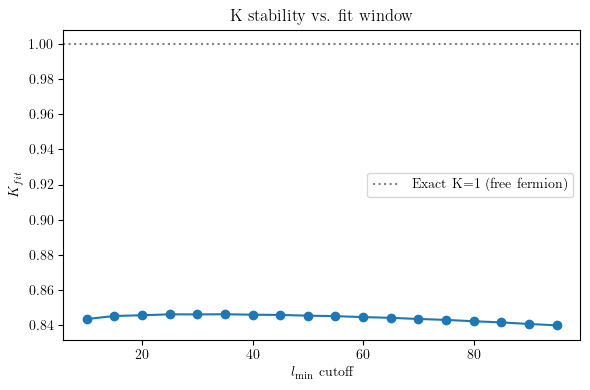

Linear Fit Results (l >= 40 and l < 90):
Slope (m) = 0.042952
R-squared = 0.999960
Extracted Luttinger Parameter K = 0.847847
Bethe Ansatz Prediction K_BA = 0.861429


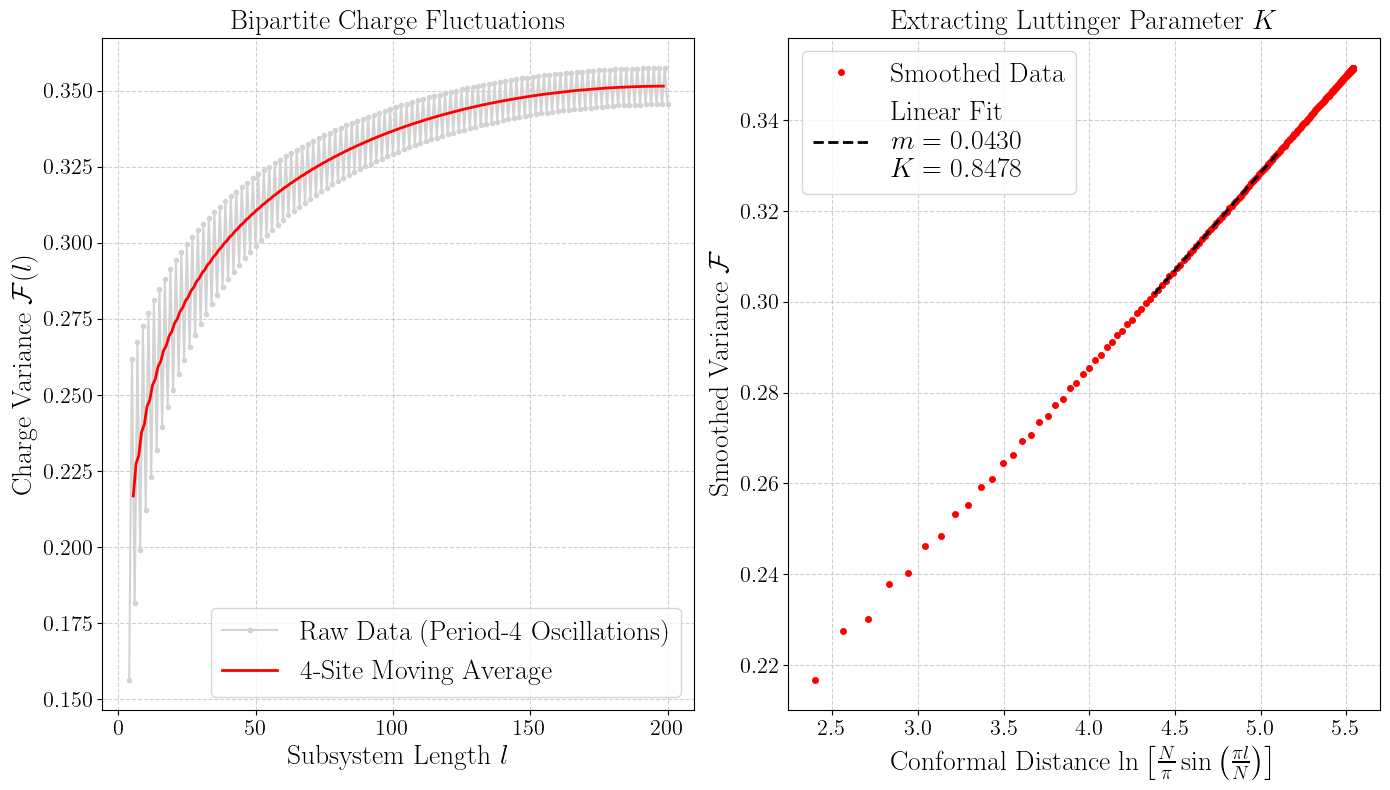

In [10]:
extract_LL_parameter_from_NNN_simulation_V05_BA()

In [11]:
def scan_fit_window(l_smooth, F_smooth, N_sites, l_min_range=range(10, 100, 5), l_max=180):
    results = []
    for lmin in l_min_range:
        mask = (l_smooth >= lmin) & (l_smooth < l_max)
        if mask.sum() < 10:
            continue
        d_l = (2 * N_sites / np.pi) * np.sin(np.pi * l_smooth[mask] / N_sites)
        slope, intercept, r, p, se = linregress(np.log(d_l), F_smooth[mask])
        results.append((lmin, slope * 2 * np.pi**2, se * 2 * np.pi**2))
    return pd.DataFrame(results, columns=["l_min", "K_fit", "K_err"])


def extract_LL_parameter_from_NNN_simulation_V00_ED_t203():
    df = pd.read_csv(project_root / "data/fluctuations/quench_paper/bipartite_fluctuations_post_quench_N400_l4-200_V00_ED_t203.csv")
    N_sites = 400

    l_raw = df['length_sub'].values
    F_raw = df['Variance'].values

    # --- 3. Apply 4-Site Moving Average ---
    window = 4
    F_smooth = np.convolve(F_raw, np.ones(window) / window, mode='valid')
    l_smooth = l_raw[0:len(F_smooth)] + (window - 1) / 2.0

    # --- 3b. Scan the fit window BEFORE committing to one ---
    scan_df = scan_fit_window(l_smooth, F_smooth, N_sites, l_min_range=range(10, 100, 5), l_max=180)
    print(scan_df.to_string(index=False))

    # Optional: quick visual of the plateau
    plt.figure(figsize=(6, 4))
    plt.errorbar(scan_df['l_min'], scan_df['K_fit'], yerr=scan_df['K_err'], fmt='o-')
    plt.axhline(1.0, color='gray', linestyle=':', label='Exact K=1 (free fermion)')
    plt.xlabel(r'$l_{\min}$ cutoff')
    plt.ylabel(r'$K_{fit}$')
    plt.legend()
    plt.title('K stability vs. fit window')
    plt.tight_layout()
    plt.show()

    # --- 4. Conformal Distance Mapping ---
    d_l = (2 * N_sites / np.pi) * np.sin(np.pi * l_smooth / N_sites)
    ln_d_l = np.log(d_l)

    # --- 5. Linear Fit (now informed by the scan above, not hand-picked) ---
    fit_mask = (l_smooth >= 40) & (l_smooth < 90)
    ln_d_l_fit = ln_d_l[fit_mask]
    F_fit = F_smooth[fit_mask]

    slope, intercept, r_value, p_value, std_err = linregress(ln_d_l_fit, F_fit)
    K_extracted = slope * (2 * np.pi ** 2)

    print("=" * 50)
    print(f"Linear Fit Results (l >= 40 and l < 90):")
    print(f"Slope (m) = {slope:.6f}")
    print(f"R-squared = {r_value**2:.6f}")
    print(f"Extracted Luttinger Parameter K = {K_extracted:.6f}")
    print("=" * 50)

    # ... rest of your plotting code unchanged ...

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

    # Plot 1: F vs l (Linear scale, showing raw vs smoothed)
    ax1.plot(l_raw, F_raw, color='lightgray', marker='o', markersize=3, linestyle='-', label="Raw Data (Period-4 Oscillations)")
    ax1.plot(l_smooth, F_smooth, color='red', linewidth=2, label="4-Site Moving Average")
    ax1.set_xlabel(r"Subsystem Length $l$", fontsize=20)
    ax1.set_ylabel(r"Charge Variance $\mathcal{F}(l)$", fontsize=20)
    ax1.set_title("Bipartite Charge Fluctuations", fontsize=20)
    ax1.legend(fontsize=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.tick_params(axis='both', which='major', labelsize=16)

    # Plot 2: F vs ln(d(l)) (Log scale mapping, showing the linear fit)
    ax2.plot(ln_d_l, F_smooth, color='red', marker='o', markersize=4, linestyle='', label="Smoothed Data")
    # Plot the fit line
    x_fit_line = np.linspace(min(ln_d_l_fit), max(ln_d_l_fit), 100)
    y_fit_line = slope * x_fit_line + intercept
    ax2.plot(x_fit_line, y_fit_line, color='black', linestyle='--', linewidth=2, 
    label=f"Linear Fit\n$m = {slope:.4f}$\n$K = {K_extracted:.4f}$")

    ax2.set_xlabel(r"Conformal Distance $\ln \left[ \frac{N}{\pi} \sin\left(\frac{\pi l}{N}\right) \right]$", fontsize=20)
    ax2.set_ylabel(r"Smoothed Variance $\mathcal{F}$", fontsize=20)
    ax2.set_title(r"Extracting Luttinger Parameter $K$", fontsize=20)
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.legend(fontsize=20)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    plt.savefig(plot_dir / "extract_LL_parameter_from_NNN_simulation_V05_N400_t200.pdf", dpi=300)
    plt.show()



 l_min    K_fit    K_err
    10 0.980002 0.000546
    15 0.982974 0.000362
    20 0.984513 0.000300
    25 0.985834 0.000233
    30 0.986647 0.000207
    35 0.987431 0.000172
    40 0.987940 0.000159
    45 0.988473 0.000138
    50 0.988821 0.000131
    55 0.989213 0.000118
    60 0.989463 0.000116
    65 0.989768 0.000107
    70 0.989951 0.000108
    75 0.990198 0.000103
    80 0.990334 0.000106
    85 0.990541 0.000105
    90 0.990640 0.000110
    95 0.990819 0.000112


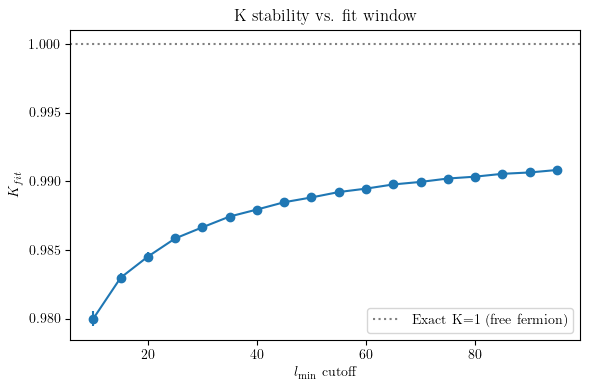

Linear Fit Results (l >= 40 and l < 90):
Slope (m) = 0.049903
R-squared = 0.999991
Extracted Luttinger Parameter K = 0.985047


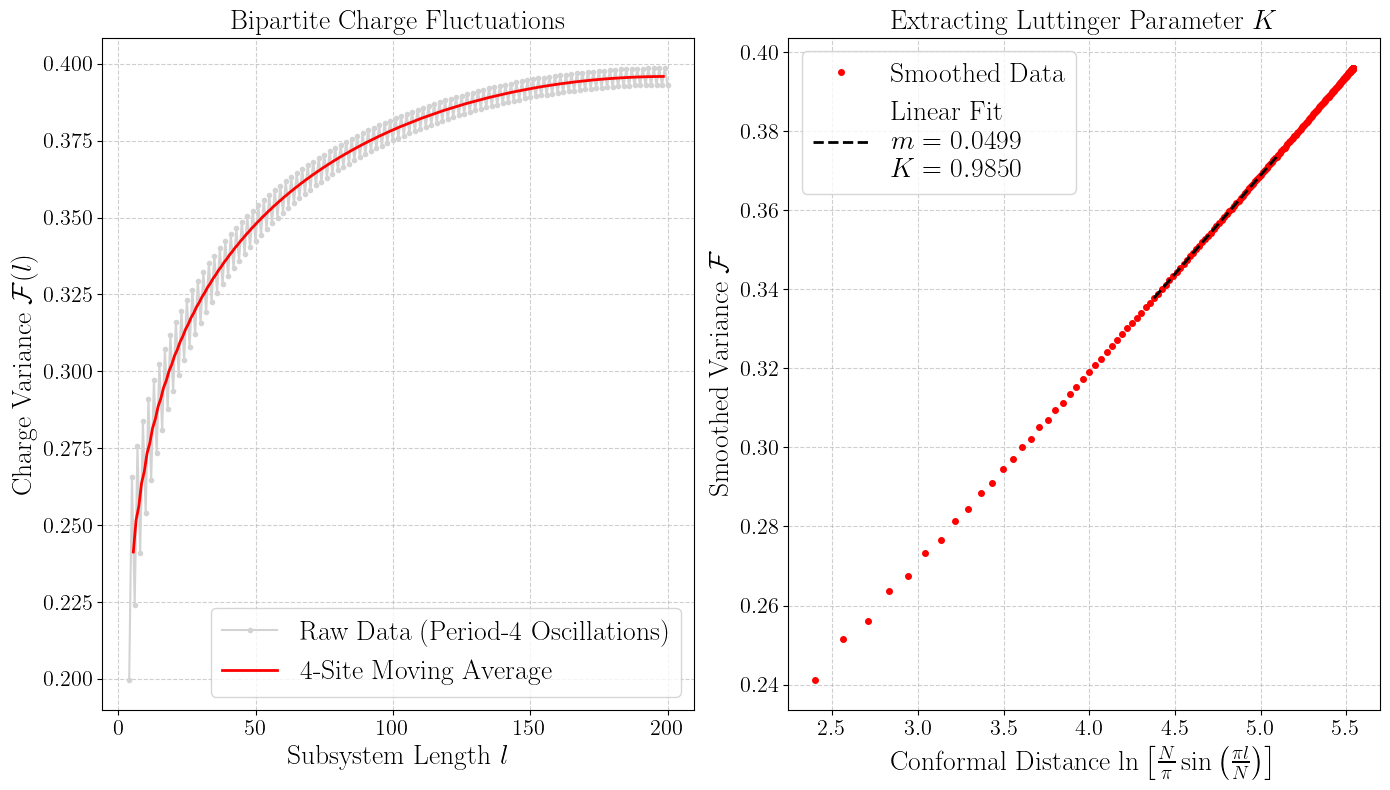

In [12]:
extract_LL_parameter_from_NNN_simulation_V00_ED_t203()

In [31]:
def scan_fit_window(l_smooth, F_smooth, N_sites, l_min_range=range(10, 100, 5), l_max=180):
    results = []
    for lmin in l_min_range:
        mask = (l_smooth >= lmin) & (l_smooth < l_max)
        if mask.sum() < 10:
            continue
        d_l = (2 * N_sites / np.pi) * np.sin(np.pi * l_smooth[mask] / N_sites)
        slope, intercept, r, p, se = linregress(np.log(d_l), F_smooth[mask])
        results.append((lmin, slope * 2 * np.pi**2, se * 2 * np.pi**2))
    return pd.DataFrame(results, columns=["l_min", "K_fit", "K_err"])


def extract_LL_parameter_from_NNN_simulation_V00_NEWGE():
    df = pd.read_csv(project_root / "data/fluctuations/quench_paper/bipartite_fluctuations_post_quench_N400_l4-200_V00_ED_t203_NEWGE_testA.csv")
    N_sites = 400

    l_raw = df['length_sub'].values
    F_raw = df['Variance'].values

    # --- 3. Apply 4-Site Moving Average ---
    window = 4
    F_smooth = np.convolve(F_raw, np.ones(window) / window, mode='valid')
    l_smooth = l_raw[0:len(F_smooth)] + (window - 1) / 2.0

    # --- 3b. Scan the fit window BEFORE committing to one ---
    scan_df = scan_fit_window(l_smooth, F_smooth, N_sites, l_min_range=range(10, 100, 5), l_max=180)
    print(scan_df.to_string(index=False))

    # Optional: quick visual of the plateau
    plt.figure(figsize=(6, 4))
    plt.errorbar(scan_df['l_min'], scan_df['K_fit'], yerr=scan_df['K_err'], fmt='o-')
    plt.axhline(1.0, color='gray', linestyle=':', label='Exact K=1 (free fermion)')
    plt.xlabel(r'$l_{\min}$ cutoff')
    plt.ylabel(r'$K_{fit}$')
    plt.legend()
    plt.title('K stability vs. fit window')
    plt.tight_layout()
    plt.show()

    # --- 4. Conformal Distance Mapping ---
    d_l = (2 * N_sites / np.pi) * np.sin(np.pi * l_smooth / N_sites)
    ln_d_l = np.log(d_l)

    # --- 5. Linear Fit (now informed by the scan above, not hand-picked) ---
    fit_mask = (l_smooth >= 40) & (l_smooth < 90)
    ln_d_l_fit = ln_d_l[fit_mask]
    F_fit = F_smooth[fit_mask]

    slope, intercept, r_value, p_value, std_err = linregress(ln_d_l_fit, F_fit)
    K_extracted = slope * (2 * np.pi ** 2)

    print("=" * 50)
    print(f"Linear Fit Results (l >= 40 and l < 90):")
    print(f"Slope (m) = {slope:.6f}")
    print(f"R-squared = {r_value**2:.6f}")
    print(f"Extracted Luttinger Parameter K = {K_extracted:.6f}")
    print("=" * 50)

    # ... rest of your plotting code unchanged ...

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

    # Plot 1: F vs l (Linear scale, showing raw vs smoothed)
    ax1.plot(l_raw, F_raw, color='lightgray', marker='o', markersize=3, linestyle='-', label="Raw Data (Period-4 Oscillations)")
    ax1.plot(l_smooth, F_smooth, color='red', linewidth=2, label="4-Site Moving Average")
    ax1.set_xlabel(r"Subsystem Length $l$", fontsize=20)
    ax1.set_ylabel(r"Charge Variance $\mathcal{F}(l)$", fontsize=20)
    ax1.set_title("Bipartite Charge Fluctuations", fontsize=20)
    ax1.legend(fontsize=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.tick_params(axis='both', which='major', labelsize=16)

    # Plot 2: F vs ln(d(l)) (Log scale mapping, showing the linear fit)
    ax2.plot(ln_d_l, F_smooth, color='red', marker='o', markersize=4, linestyle='', label="Smoothed Data")
    # Plot the fit line
    x_fit_line = np.linspace(min(ln_d_l_fit), max(ln_d_l_fit), 100)
    y_fit_line = slope * x_fit_line + intercept
    ax2.plot(x_fit_line, y_fit_line, color='black', linestyle='--', linewidth=2, 
    label=f"Linear Fit\n$m = {slope:.4f}$\n$K = {K_extracted:.4f}$")

    ax2.set_xlabel(r"Conformal Distance $\ln \left[ \frac{N}{\pi} \sin\left(\frac{\pi l}{N}\right) \right]$", fontsize=20)
    ax2.set_ylabel(r"Smoothed Variance $\mathcal{F}$", fontsize=20)
    ax2.set_title(r"Extracting Luttinger Parameter $K$", fontsize=20)
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.legend(fontsize=20)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    plt.savefig(plot_dir / "extract_LL_parameter_from_NNN_simulation_V05_N400_t200.pdf", dpi=300)
    plt.show()



 l_min    K_fit    K_err
    10 0.979933 0.000545
    15 0.982897 0.000361
    20 0.984431 0.000299
    25 0.985746 0.000232
    30 0.986552 0.000205
    35 0.987332 0.000170
    40 0.987836 0.000158
    45 0.988364 0.000136
    50 0.988708 0.000130
    55 0.989096 0.000117
    60 0.989342 0.000115
    65 0.989643 0.000106
    70 0.989823 0.000107
    75 0.990067 0.000103
    80 0.990199 0.000106
    85 0.990403 0.000105
    90 0.990499 0.000110
    95 0.990675 0.000112


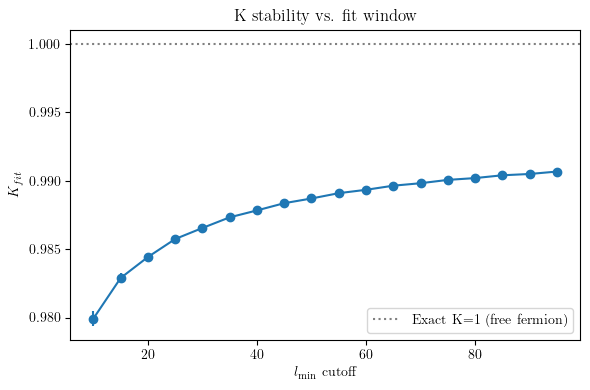

Linear Fit Results (l >= 40 and l < 90):
Slope (m) = 0.049899
R-squared = 0.999991
Extracted Luttinger Parameter K = 0.984973


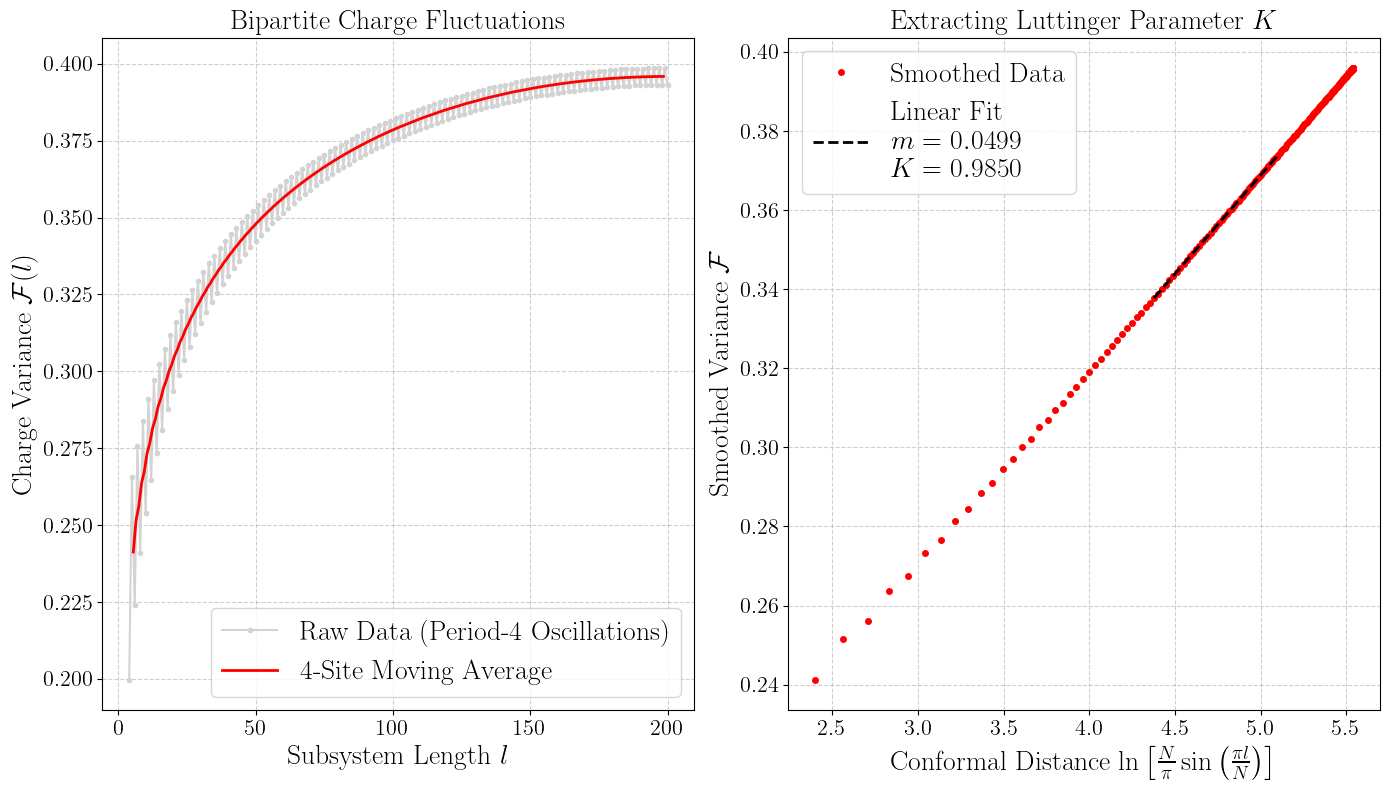

In [32]:
extract_LL_parameter_from_NNN_simulation_V00_NEWGE()

In [25]:
def scan_fit_window(l_smooth, F_smooth, N_sites, l_min_range=range(10, 400, 5), l_max=480):
    results = []
    for lmin in l_min_range:
        mask = (l_smooth >= lmin) & (l_smooth < l_max)
        if mask.sum() < 10:
            continue
        d_l = (N_sites / np.pi) * np.sin(np.pi * l_smooth[mask] / N_sites)
        slope, intercept, r, p, se = linregress(np.log(d_l), F_smooth[mask])
        results.append((lmin, slope * np.pi**2, se *  np.pi**2))
    return pd.DataFrame(results, columns=["l_min", "K_fit", "K_err"])


def extract_LL_parameter_from_NNN_simulation_V05_t203_NEWGE():
    df = pd.read_csv(project_root / "data/fluctuations/quench_paper/bipartite_fluctuations_post_quench_N1000_l4-500_V05_t203_NEWGE.csv")
    N_sites = 1000

    l_raw = df['length_sub'].values
    F_raw = df['Variance'].values

    # --- 3. Apply 4-Site Moving Average ---
    window = 4
    F_smooth = np.convolve(F_raw, np.ones(window) / window, mode='valid')
    l_smooth = l_raw[0:len(F_smooth)] + (window - 1) / 2.0

    # --- 3b. Scan the fit window BEFORE committing to one ---
    scan_df = scan_fit_window(l_smooth, F_smooth, N_sites, l_min_range=range(10, 400, 20), l_max=400)
    print(scan_df.to_string(index=False))

    # Optional: quick visual of the plateau
    plt.figure(figsize=(6, 4))
    plt.errorbar(scan_df['l_min'], scan_df['K_fit'], yerr=scan_df['K_err'], fmt='o-')
    plt.axhline(1.0, color='gray', linestyle=':', label='Exact K=1 (free fermion)')
    plt.xlabel(r'$l_{\min}$ cutoff')
    plt.ylabel(r'$K_{fit}$')
    plt.legend()
    plt.title('K stability vs. fit window')
    plt.tight_layout()
    plt.show()

    # --- 4. Conformal Distance Mapping ---
    d_l = (N_sites / np.pi) * np.sin(np.pi * l_smooth / N_sites)
    ln_d_l = np.log(d_l)

    # --- 5. Linear Fit (now informed by the scan above, not hand-picked) ---
    fit_mask = (l_smooth >= 10) & (l_smooth < 480)
    ln_d_l_fit = ln_d_l[fit_mask]
    F_fit = F_smooth[fit_mask]

    slope, intercept, r_value, p_value, std_err = linregress(ln_d_l_fit, F_fit)
    K_extracted = slope * (np.pi ** 2)

    print("=" * 50)
    print(f"Linear Fit Results (l >= 10 and l < 480):")
    print(f"Slope (m) = {slope:.6f}")
    print(f"R-squared = {r_value**2:.6f}")
    print(f"Extracted Luttinger Parameter K = {K_extracted:.6f}")
    print(f"Intercept:{intercept:.6f}")
    print("=" * 50)

    # ... rest of your plotting code unchanged ...

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

    # Plot 1: F vs l (Linear scale, showing raw vs smoothed)
    ax1.plot(l_raw, F_raw, color='lightgray', marker='o', markersize=3, linestyle='-', label="Raw Data (Period-4 Oscillations)")
    ax1.plot(l_smooth, F_smooth, color='red', linewidth=2, label="4-Site Moving Average")
    ax1.plot(l_smooth,  slope* np.log(l_smooth) + 0.218652)
    ax1.set_xlabel(r"Subsystem Length $l$", fontsize=20)
    ax1.set_ylabel(r"Charge Variance $\mathcal{F}(l)$", fontsize=20)
    ax1.set_title("Bipartite Charge Fluctuations", fontsize=20)
    ax1.legend(fontsize=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.tick_params(axis='both', which='major', labelsize=16)

    # Plot 2: F vs ln(d(l)) (Log scale mapping, showing the linear fit)
    ax2.plot(ln_d_l, F_smooth, color='red', marker='o', markersize=4, linestyle='', label="Smoothed Data")
    # Plot the fit line
    x_fit_line = np.linspace(min(ln_d_l_fit), max(ln_d_l_fit), 100)
    y_fit_line = slope * x_fit_line + intercept
    ax2.plot(x_fit_line, y_fit_line, color='black', linestyle='--', linewidth=2, 
    label=f"Linear Fit\n$m = {slope:.4f}$\n$K = {K_extracted:.4f}$")

    ax2.set_xlabel(r"Conformal Distance $\ln \left[ \frac{N}{\pi} \sin\left(\frac{\pi l}{N}\right) \right]$", fontsize=20)
    ax2.set_ylabel(r"Smoothed Variance $\mathcal{F}$", fontsize=20)
    ax2.set_title(r"Extracting Luttinger Parameter $K$", fontsize=20)
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.legend(fontsize=20)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    plt.savefig(plot_dir / "extract_LL_parameter_from_NNN_simulation_V05_N400_t200.pdf", dpi=300)
    plt.show()



 l_min    K_fit    K_err
    10 0.864703 0.000048
    30 0.864755 0.000063
    50 0.865002 0.000078
    70 0.865287 0.000095
    90 0.865565 0.000115
   110 0.865868 0.000141
   130 0.866303 0.000171
   150 0.866975 0.000203
   170 0.867945 0.000235
   190 0.869232 0.000264
   210 0.870836 0.000289
   230 0.872752 0.000308
   250 0.874945 0.000319
   270 0.877366 0.000324
   290 0.879964 0.000325
   310 0.882749 0.000323
   330 0.885687 0.000326
   350 0.888887 0.000360
   370 0.892441 0.000589
   390 0.896115 0.003495


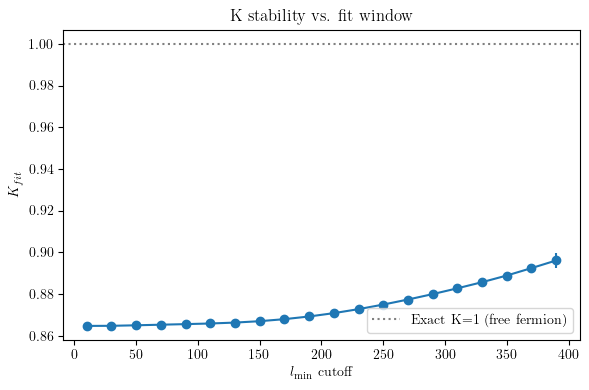

Linear Fit Results (l >= 10 and l < 480):
Slope (m) = 0.087686
R-squared = 0.999995
Extracted Luttinger Parameter K = 0.865422
Intercept:0.218652


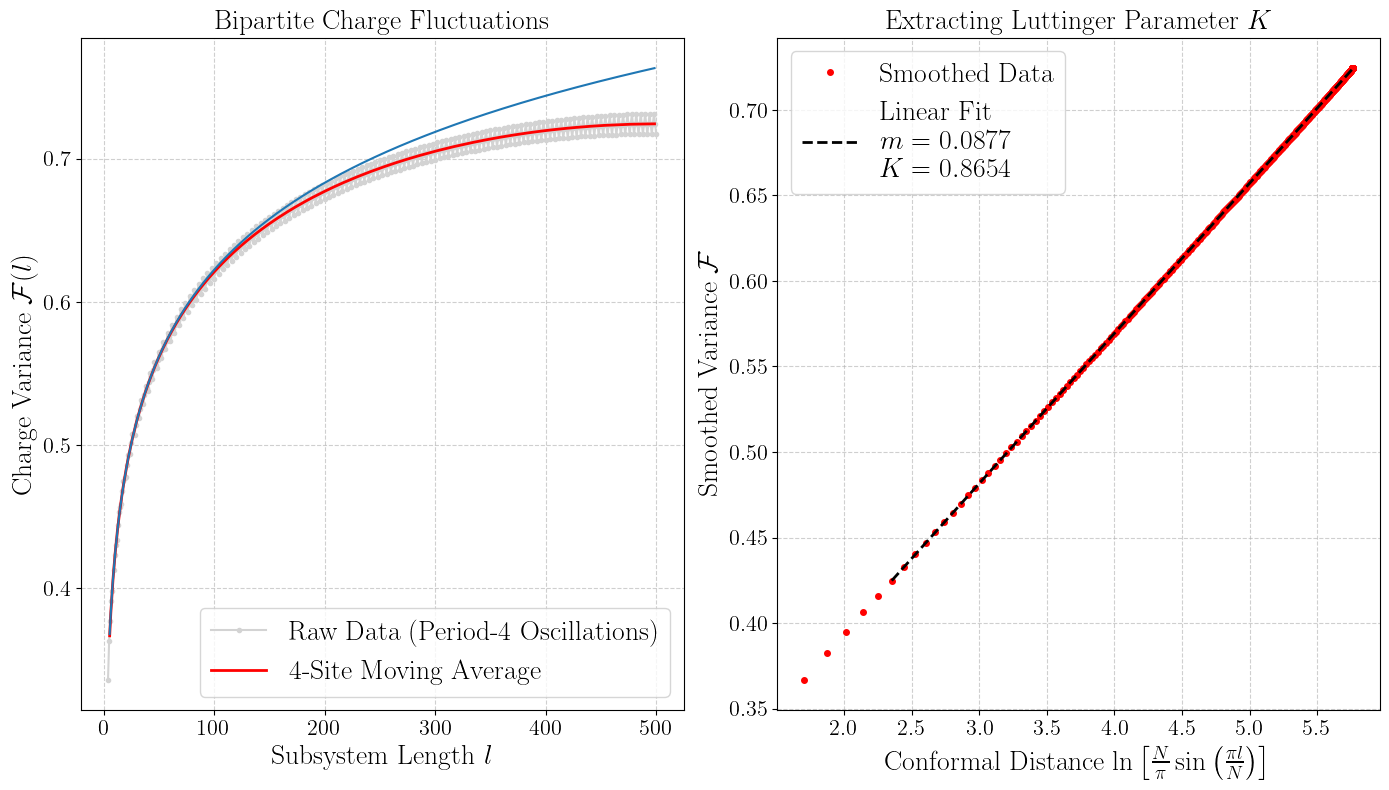

In [26]:
extract_LL_parameter_from_NNN_simulation_V05_t203_NEWGE()

In [ ]:
def scan_fit_window(l_smooth, F_smooth, N_sites, l_min_range=range(10, 400, 5), l_max=480):
    results = []
    for lmin in l_min_range:
        mask = (l_smooth >= lmin) & (l_smooth < l_max)
        if mask.sum() < 10:
            continue
        d_l = (N_sites / np.pi) * np.sin(np.pi * l_smooth[mask] / N_sites)
        slope, intercept, r, p, se = linregress(np.log(d_l), F_smooth[mask])
        results.append((lmin, slope * np.pi**2, se *  np.pi**2))
    return pd.DataFrame(results, columns=["l_min", "K_fit", "K_err"])


def extract_LL_parameter_from_NNN_simulation_V00_t203_NEWGE():
    df = pd.read_csv(project_root / "data/fluctuations/quench_paper/bipartite_fluctuations_post_quench_N1000_l4-500_V00_ED_t203_CENTERED.csv")
    N_sites = 1000

    l_raw = df['length_sub'].values
    F_raw = df['Variance'].values

    # --- 3. Apply 4-Site Moving Average ---
    window = 4
    F_smooth = np.convolve(F_raw, np.ones(window) / window, mode='valid')
    l_smooth = l_raw[0:len(F_smooth)] + (window - 1) / 2.0

    # --- 3b. Scan the fit window BEFORE committing to one ---
    scan_df = scan_fit_window(l_smooth, F_smooth, N_sites, l_min_range=range(10, 400, 20), l_max=400)
    print(scan_df.to_string(index=False))

    # Optional: quick visual of the plateau
    plt.figure(figsize=(6, 4))
    plt.errorbar(scan_df['l_min'], scan_df['K_fit'], yerr=scan_df['K_err'], fmt='o-')
    plt.axhline(1.0, color='gray', linestyle=':', label='Exact K=1 (free fermion)')
    plt.xlabel(r'$l_{\min}$ cutoff')
    plt.ylabel(r'$K_{fit}$')
    plt.legend()
    plt.title('K stability vs. fit window')
    plt.tight_layout()
    plt.show()

    # --- 4. Conformal Distance Mapping ---
    d_l = (N_sites / np.pi) * np.sin(np.pi * l_smooth / N_sites)
    ln_d_l = np.log(d_l)

    # --- 5. Linear Fit (now informed by the scan above, not hand-picked) ---
    fit_mask = (l_smooth >= 10) & (l_smooth < 480)
    ln_d_l_fit = ln_d_l[fit_mask]
    F_fit = F_smooth[fit_mask]

    slope, intercept, r_value, p_value, std_err = linregress(ln_d_l_fit, F_fit)
    K_extracted = slope * (np.pi ** 2)

    print("=" * 50)
    print(f"Linear Fit Results (l >= 10 and l < 480):")
    print(f"Slope (m) = {slope:.6f}")
    print(f"R-squared = {r_value**2:.6f}")
    print(f"Extracted Luttinger Parameter K = {K_extracted:.6f}")
    print(f"Intercept:{intercept:.6f}")
    print("=" * 50)

    # ... rest of your plotting code unchanged ...

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

    # Plot 1: F vs l (Linear scale, showing raw vs smoothed)
    ax1.plot(l_raw, F_raw, color='lightgray', marker='o', markersize=3, linestyle='-', label="Raw Data (Period-4 Oscillations)")
    ax1.plot(l_smooth, F_smooth, color='red', linewidth=2, label="4-Site Moving Average")
    ax1.set_xlabel(r"Subsystem Length $l$", fontsize=20)
    ax1.set_ylabel(r"Charge Variance $\mathcal{F}(l)$", fontsize=20)
    ax1.set_title("Bipartite Charge Fluctuations", fontsize=20)
    ax1.legend(fontsize=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.tick_params(axis='both', which='major', labelsize=16)

    # Plot 2: F vs ln(d(l)) (Log scale mapping, showing the linear fit)
    ax2.plot(ln_d_l, F_smooth, color='red', marker='o', markersize=4, linestyle='', label="Smoothed Data")
    # Plot the fit line
    x_fit_line = np.linspace(min(ln_d_l_fit), max(ln_d_l_fit), 100)
    y_fit_line = slope * x_fit_line + intercept
    ax2.plot(x_fit_line, y_fit_line, color='black', linestyle='--', linewidth=2, 
    label=f"Linear Fit\n$m = {slope:.4f}$\n$K = {K_extracted:.4f}$")

    ax2.set_xlabel(r"Conformal Distance $\ln \left[ \frac{N}{\pi} \sin\left(\frac{\pi l}{N}\right) \right]$", fontsize=20)
    ax2.set_ylabel(r"Smoothed Variance $\mathcal{F}$", fontsize=20)
    ax2.set_title(r"Extracting Luttinger Parameter $K$", fontsize=20)
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.legend(fontsize=20)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    plt.savefig(plot_dir / "extract_LL_parameter_from_NNN_simulation_V05_N400_t200.pdf", dpi=300)
    plt.show()



 l_min    K_fit    K_err
    10 0.493909 0.000152
    30 0.496001 0.000063
    50 0.496727 0.000039
    70 0.497126 0.000028
    90 0.497385 0.000021
   110 0.497569 0.000017
   130 0.497708 0.000014
   150 0.497817 0.000012
   170 0.497904 0.000011
   190 0.497975 0.000010
   210 0.498035 0.000010
   230 0.498085 0.000010
   250 0.498128 0.000011
   270 0.498164 0.000013
   290 0.498194 0.000015
   310 0.498220 0.000020
   330 0.498241 0.000028
   350 0.498256 0.000046
   370 0.498254 0.000098
   390 0.498029 0.000538


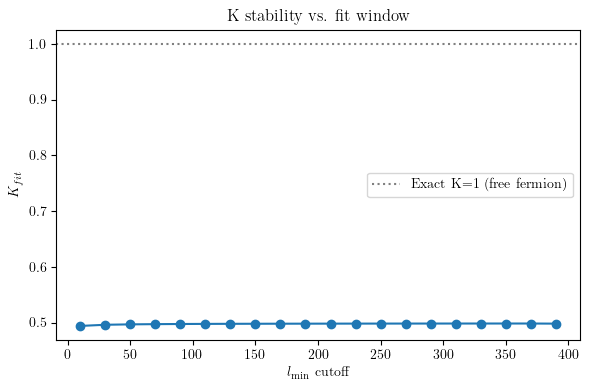

Linear Fit Results (l >= 10 and l < 480):
Slope (m) = 0.050079
R-squared = 0.999966
Extracted Luttinger Parameter K = 0.494261
Intercept:0.153433


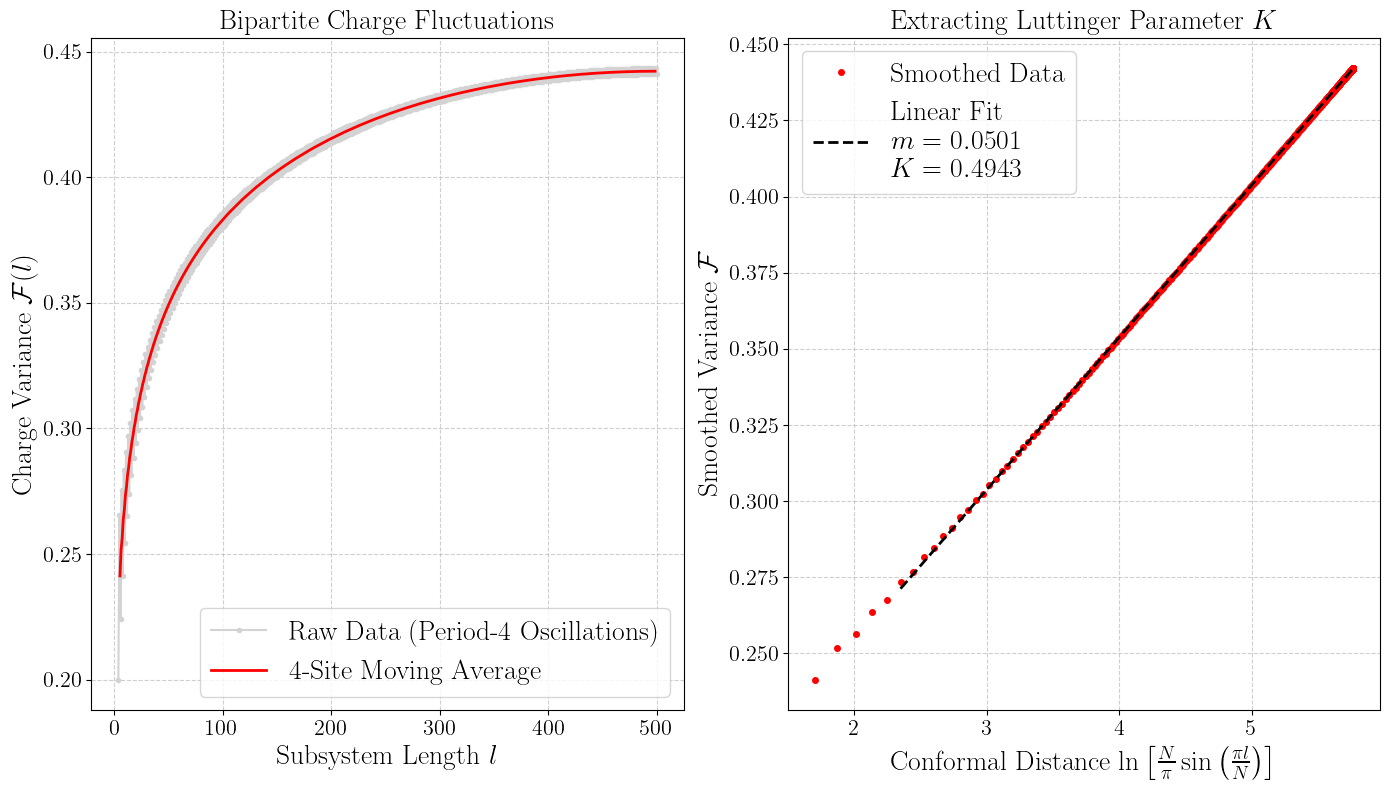

In [29]:
extract_LL_parameter_from_NNN_simulation_V00_t203_NEWGE()

In [30]:
def scan_fit_window(l_smooth, F_smooth, N_sites, l_min_range=range(10, 100, 5), l_max=180):
    results = []
    for lmin in l_min_range:
        mask = (l_smooth >= lmin) & (l_smooth < l_max)
        if mask.sum() < 10:
            continue
        d_l = (N_sites / np.pi) * np.sin(np.pi * l_smooth[mask] / N_sites)
        slope, intercept, r, p, se = linregress(np.log(d_l), F_smooth[mask])
        results.append((lmin, slope * np.pi**2, se * np.pi**2))
    return pd.DataFrame(results, columns=["l_min", "K_fit", "K_err"])


def extract_LL_parameter_from_NNN_simulation_V07_t203_NEWGE():
    df = pd.read_csv(project_root / "data/fluctuations/quench_paper/bipartite_fluctuations_post_quench_N400_l4-200_V07_t203_NEWGE.csv")
    N_sites = 400

    l_raw = df['length_sub'].values
    F_raw = df['Variance'].values

    # --- 3. Apply 4-Site Moving Average ---
    window = 4
    F_smooth = np.convolve(F_raw, np.ones(window) / window, mode='valid')
    l_smooth = l_raw[0:len(F_smooth)] + (window - 1) / 2.0

    # --- 3b. Scan the fit window BEFORE committing to one ---
    scan_df = scan_fit_window(l_smooth, F_smooth, N_sites, l_min_range=range(10, 100, 5), l_max=180)
    print(scan_df.to_string(index=False))

    # Optional: quick visual of the plateau
    plt.figure(figsize=(6, 4))
    plt.errorbar(scan_df['l_min'], scan_df['K_fit'], yerr=scan_df['K_err'], fmt='o-')
    plt.axhline(1.0, color='gray', linestyle=':', label='Exact K=1 (free fermion)')
    plt.xlabel(r'$l_{\min}$ cutoff')
    plt.ylabel(r'$K_{fit}$')
    plt.legend()
    plt.title('K stability vs. fit window')
    plt.tight_layout()
    plt.show()

    # --- 4. Conformal Distance Mapping ---
    d_l = (N_sites / np.pi) * np.sin(np.pi * l_smooth / N_sites)
    ln_d_l = np.log(d_l)

    # --- 5. Linear Fit (now informed by the scan above, not hand-picked) ---
    fit_mask = (l_smooth >= 40) & (l_smooth < 180)
    ln_d_l_fit = ln_d_l[fit_mask]
    F_fit = F_smooth[fit_mask]

    slope, intercept, r_value, p_value, std_err = linregress(ln_d_l_fit, F_fit)
    K_extracted = slope * ( np.pi**2)

    print("=" * 50)
    print(f"Linear Fit Results (l >= 40 and l < 180):")
    print(f"Slope (m) = {slope:.6f}")
    print(f"R-squared = {r_value**2:.6f}")
    print(f"Extracted Luttinger Parameter K = {K_extracted:.6f}")
    print("=" * 50)

    # ... rest of your plotting code unchanged ...

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

    # Plot 1: F vs l (Linear scale, showing raw vs smoothed)
    ax1.plot(l_raw, F_raw, color='lightgray', marker='o', markersize=3, linestyle='-', label="Raw Data (Period-4 Oscillations)")
    ax1.plot(l_smooth, F_smooth, color='red', linewidth=2, label="4-Site Moving Average")
    ax1.set_xlabel(r"Subsystem Length $l$", fontsize=20)
    ax1.set_ylabel(r"Charge Variance $\mathcal{F}(l)$", fontsize=20)
    ax1.set_title("Bipartite Charge Fluctuations", fontsize=20)
    ax1.legend(fontsize=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.tick_params(axis='both', which='major', labelsize=16)

    # Plot 2: F vs ln(d(l)) (Log scale mapping, showing the linear fit)
    ax2.plot(ln_d_l, F_smooth, color='red', marker='o', markersize=4, linestyle='', label="Smoothed Data")
    # Plot the fit line
    x_fit_line = np.linspace(min(ln_d_l_fit), max(ln_d_l_fit), 100)
    y_fit_line = slope * x_fit_line + intercept
    ax2.plot(x_fit_line, y_fit_line, color='black', linestyle='--', linewidth=2, 
    label=f"Linear Fit\n$m = {slope:.4f}$\n$K = {K_extracted:.4f}$")

    ax2.set_xlabel(r"Conformal Distance $\ln \left[ \frac{N}{\pi} \sin\left(\frac{\pi l}{N}\right) \right]$", fontsize=20)
    ax2.set_ylabel(r"Smoothed Variance $\mathcal{F}$", fontsize=20)
    ax2.set_title(r"Extracting Luttinger Parameter $K$", fontsize=20)
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.legend(fontsize=20)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    plt.savefig(plot_dir / "extract_LL_parameter_from_NNN_simulation_V05_N400_t200.pdf", dpi=300)
    plt.show()



 l_min    K_fit    K_err
    10 0.819707 0.000067
    15 0.819612 0.000071
    20 0.819640 0.000079
    25 0.819778 0.000086
    30 0.819939 0.000092
    35 0.820089 0.000100
    40 0.820254 0.000109
    45 0.820472 0.000115
    50 0.820707 0.000122
    55 0.820920 0.000132
    60 0.821141 0.000142
    65 0.821413 0.000152
    70 0.821698 0.000163
    75 0.821953 0.000179
    80 0.822218 0.000198
    85 0.822563 0.000216
    90 0.822944 0.000237
    95 0.823290 0.000266


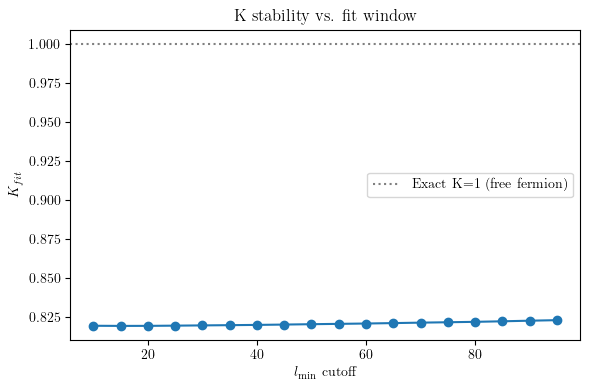

Linear Fit Results (l >= 40 and l < 180):
Slope (m) = 0.083109
R-squared = 0.999998
Extracted Luttinger Parameter K = 0.820254


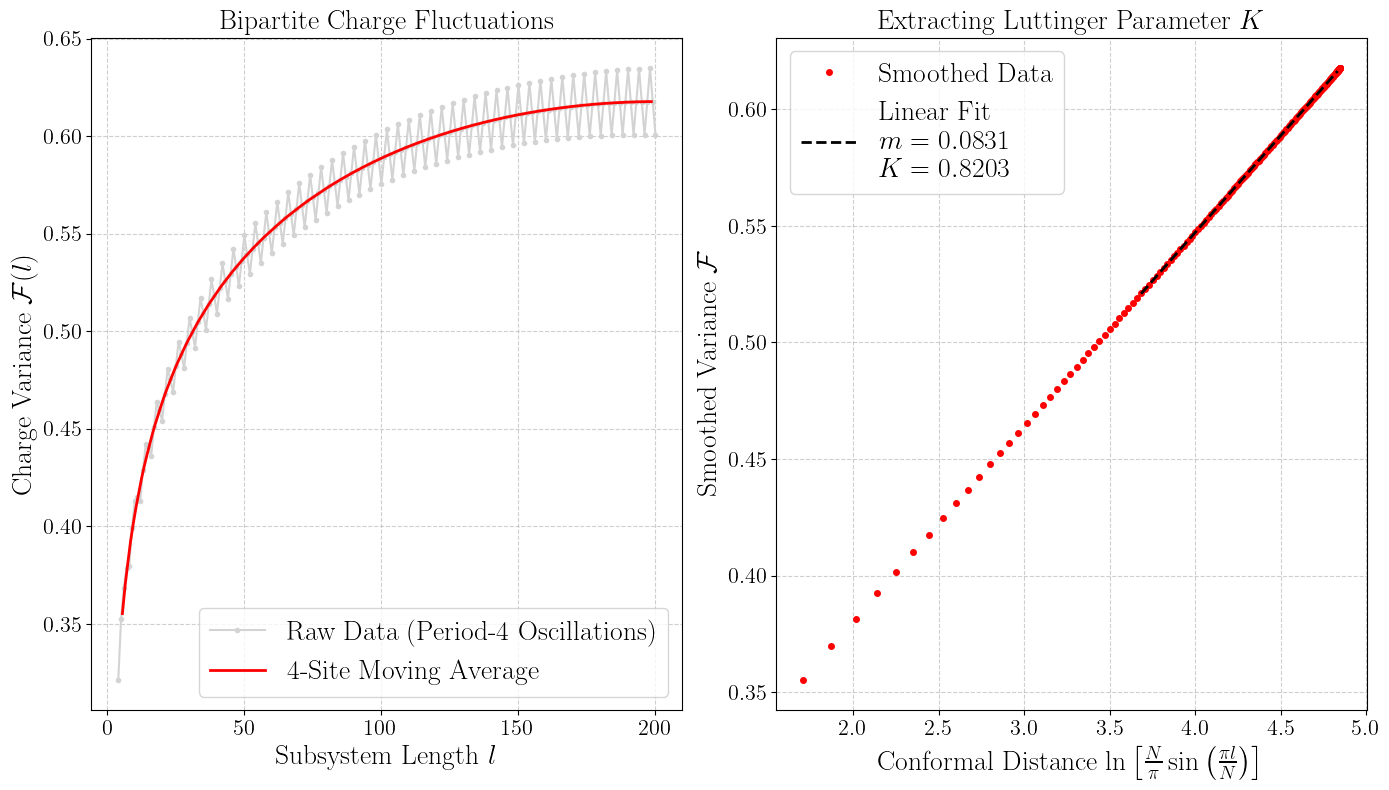

In [31]:
extract_LL_parameter_from_NNN_simulation_V07_t203_NEWGE()

In [83]:
def plot_quench_LL_to_LL_with_NNN_coupling_increase(): 
    df = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_LL_NNN_coupling_increase_V_DV02_sites400_time7.0_bonddim1800_cutoff1.0e-10_edge_subsystem_l80.csv" )

    times = df["Time"].values
    Fluctuations = df["Variance"].values

    # --- Param ---
    K_05 = 0.852646
    K_07 = 0.806539
    B_param = 0.5 * (K_05**2 - K_07**2) / (K_05 * K_07)
    m_theory = - B_param * K_07 / ( 2*np.pi**2)

    Fluctuations = Fluctuations - Fluctuations[0]  # Subtract initial value to focus on growth
    Fluctuations = Fluctuations[1:]
    times = times[1:]

    # --- perform fit ---
    mask = (times >= 3.0) & (times <= 6.0)
    times_fit = times[mask]
    Fluctuations_fit = Fluctuations[mask]
    x_data = np.log(times_fit)
    y_data = Fluctuations_fit
    slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)
    print(f"Fit Results: slope = {slope:.6f}, intercept = {intercept:.6f}, R-squared = {r_value**2:.6f}")
    
    t_line = np.linspace(0.5, 7, 200)
    fit_curve = slope * np.log(t_line) + intercept
    theory_curve = m_theory * np.log(t_line) + intercept

    fig = plt.figure(figsize=(8, 8))
    spec = gridspec.GridSpec(nrows=2, ncols=1)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = fig.add_subplot(spec[1, 0])

    l1, = ax1.plot(times, Fluctuations, color='blue',  linestyle='-', label=r"Variance $\mathcal{F}(t)$")
    ax1.set_xlabel(r"Time $t$", fontsize=20)
    ax1.set_ylabel(r"Variance $\mathcal{F}(t)$", fontsize=20)
    ax1.set_title(r"Bipartite Fluctuations Over Time $V = 0.5 \to 0.7$", fontsize=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    leg1 = ax1.legend(handles=[l1], fontsize=16, loc= 'best')
    for text, color in zip(leg1.get_texts(), ['blue']):
        text.set_color(color)


    l2, = ax2.semilogx(times, Fluctuations, color='red', linestyle='-', label=r"Variance $\mathcal{F}(t)$")
    l3, = ax2.semilogx(t_line, fit_curve, color='black', linestyle='--', linewidth=2, label=f"Linear Fit\n$m = {slope:.4f}$")
    l4, = ax2.semilogx(t_line, theory_curve, color='green', linestyle=':', linewidth=2, label=f"Theory\n$m = {m_theory:.4f}$")
    ax2.set_xlabel(r"Time $t$ (log scale)", fontsize=20)
    ax2.set_ylabel(r"Variance $\mathcal{F}(t)$", fontsize=20)
    ax2.grid(True, linestyle='--', alpha=0.6)
    leg2 = ax2.legend(handles=[l2, l3, l4], fontsize=16, loc= 'best')
    for text, color in zip(leg2.get_texts(), ['red', 'black', 'green']):
        text.set_color(color)

    plt.tight_layout()
    plt.show()


Fit Results: slope = -0.001119, intercept = -0.007388, R-squared = 0.991001


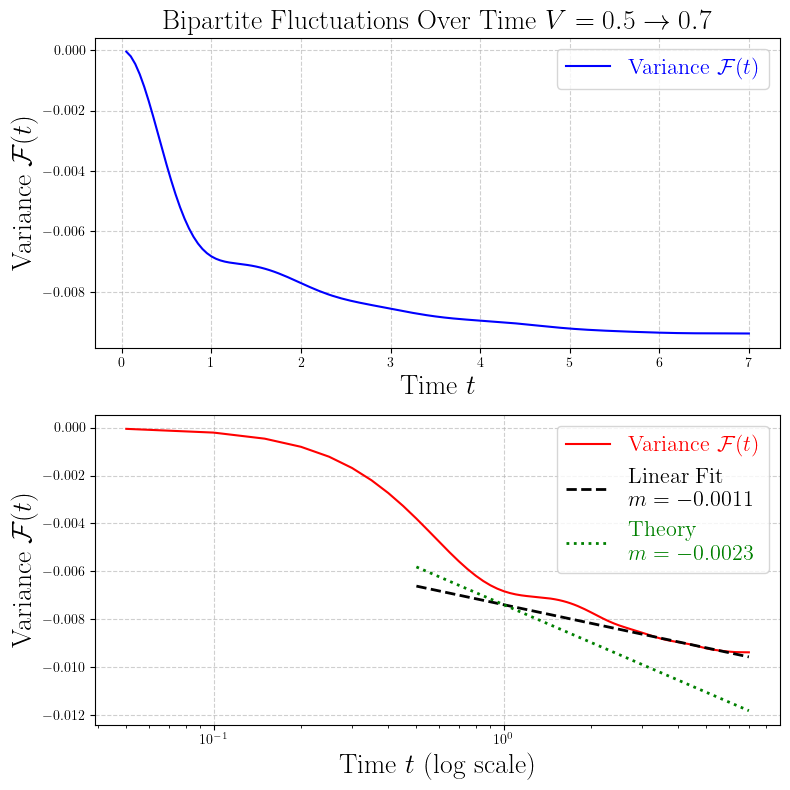

In [84]:
plot_quench_LL_to_LL_with_NNN_coupling_increase()

In [101]:
def plot_quench_LL_to_LL_with_NNN_coupling_decrease(): 
    df = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_LL_NNN_coupling_decrease_V_DV02_sites400_time7.0_bonddim1800_cutoff1.0e-10_edge_subsystem_l80.csv" )

    times = df["Time"].values
    Fluctuations = df["Variance"].values

    # --- Param ---
    K_05 = 0.852646
    K_07 = 0.806539
    B_param = 0.5 * (K_07**2 - K_05**2) / (K_05 * K_07)
    m_theory = - B_param * K_05 / ( 2*np.pi**2) 

    Fluctuations = Fluctuations - Fluctuations[0]  # Subtract initial value to focus on growth
    Fluctuations = Fluctuations[1:]
    times = times[1:]

    # --- perform fit ---
    mask = (times >= 2.0) & (times <= 6.0)
    times_fit = times[mask]
    Fluctuations_fit = Fluctuations[mask]
    x_data = np.log(times_fit)
    y_data = Fluctuations_fit
    slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)
    print(f"Fit Results: slope = {slope:.6f}, intercept = {intercept:.6f}, R-squared = {r_value**2:.6f}")
    print(f"m_theory:  {m_theory:.6f}, m_fit: {slope:.6f}")
    
    t_line = np.linspace(0.5, 7, 200)
    fit_curve = slope * np.log(t_line) + intercept
    theory_curve = m_theory * np.log(t_line) + intercept

    fig = plt.figure(figsize=(8, 8))
    spec = gridspec.GridSpec(nrows=2, ncols=1)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = fig.add_subplot(spec[1, 0])

    l1, = ax1.plot(times, Fluctuations, color='blue',  linestyle='-', label=r"Variance $\mathcal{F}(t)$")
    ax1.set_xlabel(r"Time $t$", fontsize=20)
    ax1.set_ylabel(r"Variance $\mathcal{F}(t)$", fontsize=20)
    ax1.set_title(r"Bipartite Fluctuations Over Time $V = 0.7 \to 0.5$, edge sub", fontsize=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    leg1 = ax1.legend(handles=[l1], fontsize=16, loc= 'best')
    for text, color in zip(leg1.get_texts(), ['blue']):
        text.set_color(color)


    l2, = ax2.semilogx(times, Fluctuations, color='red', linestyle='-', label=r"Variance $\mathcal{F}(t)$")
    l3, = ax2.semilogx(t_line, fit_curve, color='black', linestyle='--', linewidth=2, label=f"Linear Fit\n$m = {slope:.4f}$")
    l4, = ax2.semilogx(t_line, theory_curve, color='green', linestyle=':', linewidth=2, label=f"Theory\n$m = {m_theory:.4f}$")
    ax2.set_xlabel(r"Time $t$ (log scale)", fontsize=20)
    ax2.set_ylabel(r"Variance $\mathcal{F}(t)$", fontsize=20)
    ax2.grid(True, linestyle='--', alpha=0.6)
    leg2 = ax2.legend(handles=[l2, l3, l4], fontsize=16, loc= 'best')
    for text, color in zip(leg2.get_texts(), ['red', 'black', 'green']):
        text.set_color(color)

    plt.tight_layout()
    plt.show()


Fit Results: slope = 0.004032, intercept = 0.005858, R-squared = 0.997333
m_theory:  0.002403, m_fit: 0.004032


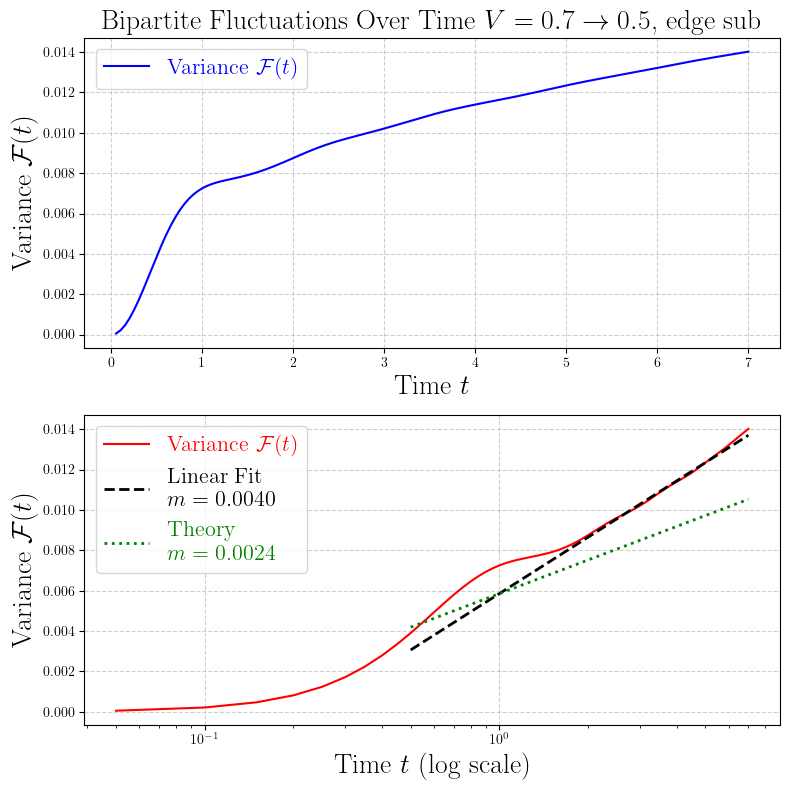

In [102]:
plot_quench_LL_to_LL_with_NNN_coupling_decrease()

In [33]:
def scan_fit_window_time(times, Fluctuations, t_min_range, t_max_range, min_points=5):
    """
    2D scan of the log-time linear fit over (t_min, t_max) windows.
    times, Fluctuations: already ΔF(t) = F(t)-F(0), with t=0 point dropped.
    Returns a long-format DataFrame with slope, slope_err, R2, n_points
    for every valid (t_min, t_max) combination with t_max > t_min.
    """
    results = []
    ln_t_all = np.log(times)
    for t_min in t_min_range:
        for t_max in t_max_range:
            if t_max <= t_min:
                continue
            mask = (times >= t_min) & (times <= t_max)
            if mask.sum() < min_points:
                continue
            slope, intercept, r_value, p_value, std_err = linregress(
                ln_t_all[mask], Fluctuations[mask]
            )
            results.append((t_min, t_max, slope, std_err, r_value**2, mask.sum()))
    return pd.DataFrame(results, columns=["t_min", "t_max", "slope", "slope_err", "R2", "n_points"])


def plot_window_scan_heatmap(scan_df, m_theory):
    pivot = scan_df.pivot(index="t_min", columns="t_max", values="slope")
    ratio = pivot / m_theory

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(ratio.values, aspect='auto', origin='lower',
                    extent=[pivot.columns.min(), pivot.columns.max(),
                            pivot.index.min(), pivot.index.max()],
                    cmap='RdBu_r', vmin=0.7, vmax=1.3)
    plt.colorbar(im, label=r"$m_{fit} / m_{theory}$")
    ax.set_xlabel(r"$t_{max}$")
    ax.set_ylabel(r"$t_{min}$")
    ax.set_title("Slope ratio vs. fit window")
    plt.tight_layout()
    plt.show()
    return ratio

def plot_quench_LL_to_LL_decrease_map_with_bethe_ansatz_centered(): 
    df = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_sites400_time7.0_bonddim1800_cutoff1.0e-10_centered_subsystem_l80_new.csv" )
    df1 = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_sites800_time7.0_bonddim1800_cutoff1.0e-10_centered_subsystem_l80_new.csv")
    df2 = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_sites1200_time7.0_bonddim1800_cutoff1.0e-10_centered_subsystem_l80_new.csv")

    times = df["Time"].values
    Fluctuations = df["Variance"].values
    times1 = df1["Time"].values
    Fluctuations1 = df1["Variance"].values
    times2 = df2["Time"].values
    Fluctuations2 = df2["Variance"].values

    # --- Param Bethe Ansatz---
    V_i = 0.7
    V_f = 0.5
    mu_i = np.arccos(V_i / 2)
    mu_f = np.arccos(V_f / 2)

    K_i = np.pi / (2 * (np.pi - mu_i))
    K_f = np.pi / (2 * (np.pi - mu_f))

    B_param = 0.5 * (K_i**2 - K_f**2) / (K_i * K_f)
    m_theory = - B_param * K_f / ( np.pi**2) 



    Fluctuations = Fluctuations - Fluctuations[0]  # Subtract initial value to focus on growth
    Fluctuations = Fluctuations[1:]
    times = times[1:]

    Fluctuations1 = Fluctuations1 - Fluctuations1[0]  # Subtract initial value to focus on growth
    Fluctuations1 = Fluctuations1[1:]
    times1 = times1[1:]

    Fluctuations2 = Fluctuations2 - Fluctuations2[0]  # Subtract initial value to focus on growth
    Fluctuations2 = Fluctuations2[1:]
    times2 = times2[1:]

    # --- perform fit ---
    mask = (times2 >= 2.0) & (times2 <= 4.0)
    times_fit = times2[mask]
    Fluctuations_fit = Fluctuations2[mask]
    x_data = np.log(times_fit)
    y_data = Fluctuations_fit
    slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)
    print(f"Fit Results: slope = {slope:.6f}, intercept = {intercept:.6f}, R-squared = {r_value**2:.6f}")
    print(f"m_theory:  {m_theory:.6f}, m_fit: {slope:.6f}, error_percentage: {abs((slope - m_theory)/m_theory)*100:.2f}%")
    
    t_line = np.linspace(0.5, 7, 200)
    fit_curve = slope * np.log(t_line) + intercept
    theory_curve = m_theory * np.log(t_line) + intercept

    fig = plt.figure(figsize=(8, 8))
    spec = gridspec.GridSpec(nrows=2, ncols=1)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = fig.add_subplot(spec[1, 0])

    l1, = ax1.plot(times, Fluctuations, color='blue',  linestyle='-', label=r"Variance $\mathcal{F}(t)$")
    ax1.set_xlabel(r"Time $t$", fontsize=20)    
    ax1.set_ylabel(r" $\Delta \mathcal{F}(t)$", fontsize=20)
    ax1.set_title(r"Bipartite Fluctuations Over Time $V = 0.7 \to 0.5$, centered sub", fontsize=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    leg1 = ax1.legend(handles=[l1], fontsize=16, loc= 'best')
    for text, color in zip(leg1.get_texts(), ['blue']):
        text.set_color(color)


    l2, = ax2.semilogx(times, Fluctuations, color='red', linestyle='-', label=r"Variance $\mathcal{F}(t)$")
    #l3, = ax2.semilogx(t_line, fit_curve, color='black', linestyle='--', linewidth=2, label=f"Linear Fit\n$m = {slope:.4f}$")
    l4, = ax2.semilogx(t_line, theory_curve, color='green', linestyle=':', linewidth=2, label=f"Theory\n$m = {m_theory:.4f}$")
    l5, = ax2.semilogx(times1, Fluctuations1, color='orange', linestyle='-', label=r"Variance $\mathcal{F}(t)$ (N=800)")
    l6, = ax2.semilogx(times2, Fluctuations2, color='purple', linestyle='-', label=r"Variance $\mathcal{F}(t)$ (N=1200)")
    ax2.set_xlabel(r"Time $t$ (log scale)", fontsize=20)
    ax2.set_ylabel(r"$\Delta \mathcal{F}(t)$", fontsize=20)
    ax2.grid(True, linestyle='--', alpha=0.6)
    leg2 = ax2.legend(handles=[l2, l4, l5, l6], fontsize=16, loc= 'best')
    for text, color in zip(leg2.get_texts(), ['red', 'green', 'orange', 'purple']):
        text.set_color(color)

    t_min_range = np.arange(0.5, 4.0, 0.25)
    t_max_range = np.arange(2.0, 7.0, 0.25)
    scan_df = scan_fit_window_time(times, Fluctuations, t_min_range, t_max_range, min_points=8)
    ratio = plot_window_scan_heatmap(scan_df, m_theory)

    best = scan_df.iloc[(scan_df['slope'] - m_theory).abs().argsort()[:10]]
    print(best)

    plt.tight_layout()
    plt.show()


Fit Results: slope = 0.005554, intercept = 0.011693, R-squared = 0.996310
m_theory:  0.004884, m_fit: 0.005554, error_percentage: 13.71%


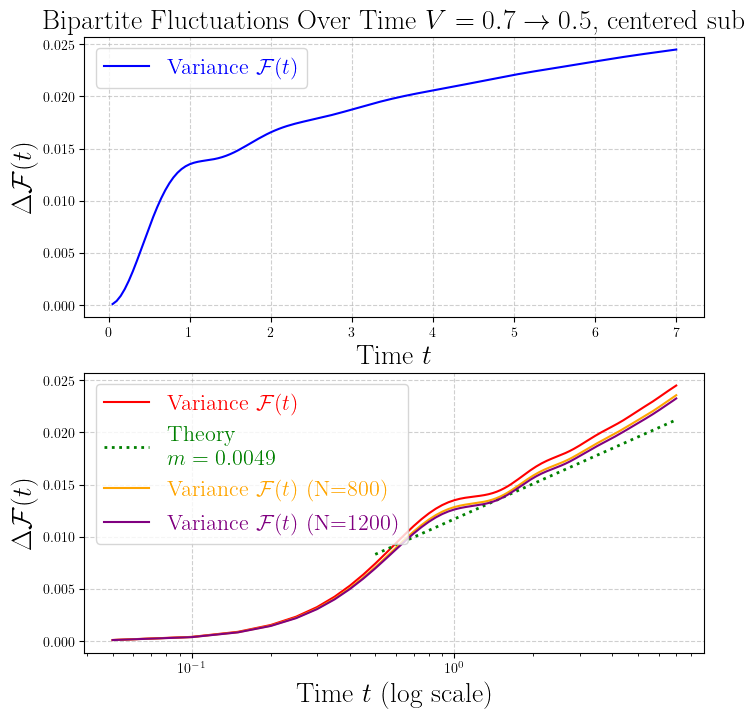

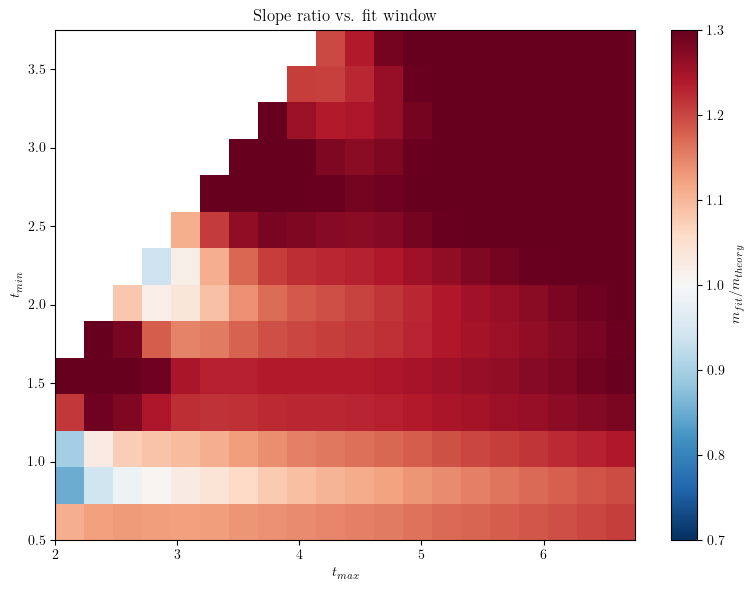

     t_min  t_max     slope  slope_err        R2  n_points
23    0.75   2.75  0.004918   0.000138  0.970333        41
22    0.75   2.50  0.004813   0.000164  0.961964        36
138   2.25   3.00  0.004974   0.000092  0.995257        16
120   2.00   2.75  0.004976   0.000095  0.994924        16
24    0.75   3.00  0.004999   0.000118  0.976013        46
41    1.00   2.25  0.005010   0.000269  0.935299        26
121   2.00   3.00  0.005067   0.000065  0.996891        21
25    0.75   3.25  0.005089   0.000105  0.979589        51
21    0.75   2.25  0.004591   0.000192  0.951852        31
26    0.75   3.50  0.005181   0.000096  0.981877        56


<Figure size 640x480 with 0 Axes>

In [34]:
plot_quench_LL_to_LL_decrease_map_with_bethe_ansatz_centered()

In [26]:

def figure_1_paper(): 
    
    df = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_sites400_time7.0_bonddim1800_cutoff1.0e-10_centered_subsystem_l80_new.csv" )
    df1 = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_sites800_time7.0_bonddim1800_cutoff1.0e-10_centered_subsystem_l80_new.csv")
    df2 = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_sites1200_time7.0_bonddim1800_cutoff1.0e-10_centered_subsystem_l80_new.csv")

    times = df["Time"].values
    Fluctuations = df["Variance"].values
    times1 = df1["Time"].values
    Fluctuations1 = df1["Variance"].values
    times2 = df2["Time"].values
    Fluctuations2 = df2["Variance"].values

    # --- Param Bethe Ansatz---
    V_i = 0.7
    V_f = 0.5
    mu_i = np.arccos(V_i / 2)
    mu_f = np.arccos(V_f / 2)

    K_i = np.pi / (2 * (np.pi - mu_i))
    K_f = np.pi / (2 * (np.pi - mu_f))

    print(K_i)
    print(K_f)

    B_param = 0.5 * (K_i**2 - K_f**2) / (K_i * K_f)
    m_theory = - B_param * K_f / ( np.pi**2) 

    Fluctuations = Fluctuations - Fluctuations[0]  
    Fluctuations = Fluctuations[1:]
    times = times[1:]

    Fluctuations1 = Fluctuations1 - Fluctuations1[0]  
    Fluctuations1 = Fluctuations1[1:]
    times1 = times1[1:]

    Fluctuations2 = Fluctuations2 - Fluctuations2[0]  
    Fluctuations2 = Fluctuations2[1:]
    times2 = times2[1:]

    # --- perform fit ---
    mask = (times2 >= 2.0) & (times2 <= 4.0)
    times_fit = times2[mask]
    Fluctuations_fit = Fluctuations2[mask]
    x_data = np.log(times_fit)
    y_data = Fluctuations_fit
    slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)
    
    print(f"Fit Results: slope = {slope:.6f}, intercept = {intercept:.6f}, R-squared = {r_value**2:.6f}")
    print(f"m_theory:  {m_theory:.6f}, m_fit: {slope:.6f}, error_percentage: {abs((slope - m_theory)/m_theory)*100:.2f}%")
    
    t_line = np.linspace(0.5, 7, 200)
    # fit_curve = slope * np.log(t_line) + intercept
    theory_curve = m_theory * np.log(t_line) + intercept

    # --- Plotting ---
    fig = plt.figure(figsize=(8, 5))
    spec = gridspec.GridSpec(nrows=1, ncols=1)
    ax = fig.add_subplot(spec[0, 0])

    # Plot data using open markers and no connecting lines to mimic Fig 4
    # The 'markevery' parameter prevents the markers from clustering too heavily if you have many data points
    m_spacing = 10 
    
    l2, = ax.semilogx(times, Fluctuations, color='dodgerblue', marker='o', markerfacecolor='none', 
                      linestyle='None', markevery=m_spacing, label=r"$N=400$")
    l5, = ax.semilogx(times1, Fluctuations1, color='royalblue', marker='p', markerfacecolor='none', 
                      linestyle='None', markevery=m_spacing, label=r"$N=800$")
    l6, = ax.semilogx(times2, Fluctuations2, color='mediumorchid', marker='s', markerfacecolor='none', 
                      linestyle='None', markevery=m_spacing, label=r"$N=1200$")
    
    # Plot theory as a dashed black line, similar to the reference lines in the paper
    l4, = ax.semilogx(t_line, theory_curve, color='black', linestyle='--', linewidth=1.0)

    # Axes and grid styling
    ax.set_xlabel(r"Time $t$", fontsize=16)
    ax.set_ylabel(r"$\Delta \mathcal{F}(t)$", fontsize=16)
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14)
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.set_xlim(0.4, 7)
    ax.set_ylim(0.005, 0.025)
    
    # Keeping grid subtle
    ax.grid(True, which="major", linestyle='--', alpha=0.4)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
    ax.yaxis.get_offset_text().set_fontsize(14)
    
    # Legend
    leg = ax.legend(handles=[l2, l5, l6], fontsize=20, loc='best', frameon=True, edgecolor= 'lightgray')

    # --- Adding the Annotation Arrow ---
    target_x = 0.8
    target_y = intercept - 0.001
    
    # Adjust xytext to move the starting point of the text/arrow. 
    # Here it places the text slightly to the left (0.6) and up (+0.003) from the line.
    text_x = 0.6
    text_y = intercept + 0.001 

    ax.annotate(r"$-B K_f \ln(t)$", 
                xy=(target_x, target_y), 
                xytext=(text_x, text_y), 
                arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
                fontsize=14,
                ha='center', 
                va='center')
    def full_pretime_ansatz(t, BKf, alpha, uf, l):
        term1 = np.log((alpha**2 + (l - 2*uf*t)**2) / (alpha**2 + (2*uf*t)**2))
        term2 = np.log((alpha**2 + (l + 2*uf*t)**2) / (alpha**2 + (2*uf*t)**2))
        const = np.log((alpha**2 + l**2) / alpha**2)
        return (BKf/4)*(term1 + term2) - (BKf/2)*const

    l_fixed = 80.0
    u_fixed = 2.425  # known exactly, by construction

    def model(t, BKf, alpha):
        return full_pretime_ansatz(t, BKf, alpha, l_fixed, u_fixed) / np.pi**2

    from scipy.optimize import curve_fit

    popt, pcov = curve_fit(model, times2, Fluctuations2, p0=[B_param*K_f, 1.0],
                        bounds=([-np.inf, 0.01], [0, 10]))
    BKf_fit, alpha_fit = popt
    print(f"Fitted B*Kf = {BKf_fit:.6f}  (theory: {B_param*K_f:.6f}, ratio: {BKf_fit/(B_param*K_f):.4f})")
    print(f"Fitted alpha (cutoff) = {alpha_fit:.4f}")

    plt.tight_layout()
    plt.savefig(plot_dir / "figure_1.pdf", dpi=300)

    plt.show()


# figure_1_paper()

0.8145731472119673
0.8614293939143047
Fit Results: slope = 0.005554, intercept = 0.011693, R-squared = 0.996310
m_theory:  0.004884, m_fit: 0.005554, error_percentage: 13.71%
Fitted B*Kf = -0.031001  (theory: -0.048204, ratio: 0.6431)
Fitted alpha (cutoff) = 0.0100


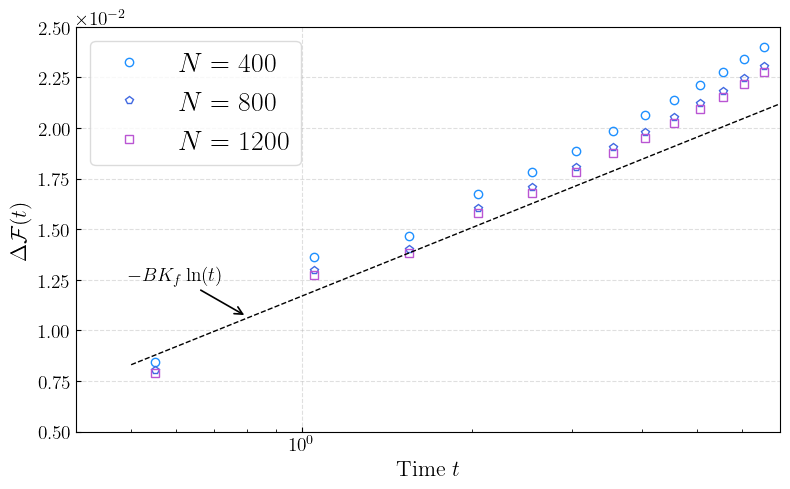

In [27]:
figure_1_paper()

In [5]:
filename = checkpoint_dir / "quench_from_LL_to_LL_NNN_coupling_bd1600_1200_decrease_V_DV02_7.0_edge_subsystem_l80.h5"
with h5py.File(filename, 'r') as f: 
    print ("Available keys in the h5 file: ", list(f.keys()))

    variance = np.array(f['F_vals'])

    if 'times' in f.keys():
            time = np.array(f['times'])
            print("if")
    else:
          t_current = float(np.array(f['t']))
          time = np.linspace(0.0, t_current, len(variance))
          print("else")

    time = np.round(time, 2)

df = pd.DataFrame({'Time': time, 'Variance': variance})

output_csv = data_quench_dir / "quench_from_LL_to_LL_NNN_coupling_decrease_V_DV02_sites1200_time7.0_bonddim1600_cutoff1e-10_central_subsystem_l80.csv"
df.to_csv(output_csv, index=False)







Available keys in the h5 file:  ['F_vals', 'S_EE_vals', 'psi', 'step', 't', 'total_fidelity']
else


In [ ]:

def figure_2_paper(): 
    # NEED TO UPDATE TH DAHED LINE WITH THE CORRECT K!!!!!!!!

    df = pd.read_csv(data_quench_dir / "quench_from_LL_to_LL_NNN_coupling_decrease_V_DV02_sites400_time7.0_bonddim1600_cutoff1.0e-10_central_subsystem_l80.csv" )
    df_a = pd.read_csv(data_quench_dir / "NNN/quench_NNN_ctr-N400_t20.3_V0.7.csv" )
    df1 = pd.read_csv(data_quench_dir / "quench_from_LL_to_LL_NNN_coupling_decrease_V_DV02_sites800_time7.0_bonddim1600_cutoff1.0e-10_central_subsystem_l80.csv")
    df2 = pd.read_csv(data_quench_dir / "quench_from_LL_to_LL_NNN_coupling_decrease_V_DV02_sites1200_time7.0_bonddim1600_cutoff1e-10_central_subsystem_l80.csv")

    times = df["Time"].values
    Fluctuations = df["Variance"].values
    times_a = df_a["Time"].values
    Fluctuations_a = df_a["Variance"].values
    times1 = df1["Time"].values
    Fluctuations1 = df1["Variance"].values
    times2 = df2["Time"].values
    Fluctuations2 = df2["Variance"].values

    # --- Param Bethe Ansatz--- NEED TO UPDATE THESE PARAM WITHT HE CORRECT ONES, NO BETHE ANSATZ FOR NNN COUPLING
    

    K_05 = 0.8654
    K_07 = 0.806539

    K_i = K_07
    K_f = K_05

    B_param = 0.5 * (K_i**2 - K_f**2) / (K_i * K_f)
    m_theory = - B_param * K_f / ( np.pi**2) 

    Fluctuations = Fluctuations - Fluctuations[0]  
    Fluctuations = Fluctuations[1:]
    times = times[1:]

    Fluctuations_a = Fluctuations_a - Fluctuations_a[0]  
    Fluctuations_a = Fluctuations_a[1:]
    times_a = times_a[1:]

    Fluctuations1 = Fluctuations1 - Fluctuations1[0]  
    Fluctuations1 = Fluctuations1[1:]
    times1 = times1[1:]

    Fluctuations2 = Fluctuations2 - Fluctuations2[0]  
    Fluctuations2 = Fluctuations2[1:]
    times2 = times2[1:]

    # --- perform fit ---
    mask = (times >= 2.0) & (times <= 4.0)
    times_fit = times[mask]
    Fluctuations_fit = Fluctuations[mask]
    x_data = np.log(times_fit)
    y_data = Fluctuations_fit
    slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)
    
    print(f"Fit Results: slope = {slope:.6f}, intercept = {intercept:.6f}, R-squared = {r_value**2:.6f}")
    print(f"m_theory:  {m_theory:.6f}, m_fit: {slope:.6f}, error_percentage: {abs((slope - m_theory)/m_theory)*100:.2f}%")
    
    t_line = np.linspace(0.5, 7, 200)
    fit_curve = slope * np.log(t_line) + intercept
    theory_curve = m_theory * np.log(t_line) + intercept

    # --- Plotting ---
    fig = plt.figure(figsize=(8, 5))
    spec = gridspec.GridSpec(nrows=1, ncols=1)
    ax = fig.add_subplot(spec[0, 0])

    # Plot data using open markers and no connecting lines to mimic Fig 4
    # The 'markevery' parameter prevents the markers from clustering too heavily if you have many data points
    m_spacing = 10 
    
    l2, = ax.semilogx(times, Fluctuations, color='dodgerblue', marker='o', markerfacecolor='none', 
                      linestyle='None', markevery=m_spacing, label=r"$N=400$")
    l2_a, = ax.semilogx(times_a, Fluctuations_a, color='blue', marker='o', markerfacecolor='none', 
                          linestyle='None', markevery=50, label=r"$N=400$, $dt=0.01$")
    l5, = ax.semilogx(times1, Fluctuations1, color='royalblue', marker='p', markerfacecolor='none', 
                      linestyle='None', markevery=m_spacing, label=r"$N=800$")
    l6, = ax.semilogx(times2, Fluctuations2, color='mediumorchid', marker='s', markerfacecolor='none', 
                      linestyle='None', markevery=m_spacing, label=r"$N=1200$")

    # Plot theory as a dashed black line, similar to the reference lines in the paper
    l4, = ax.semilogx(t_line, theory_curve, color='black', linestyle='--', linewidth=1.0)

    # Axes and grid styling
    ax.set_xlabel(r"Time $t$", fontsize=16)
    ax.set_ylabel(r"$\Delta \mathcal{F}(t)$", fontsize=16)
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14)
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.set_xlim(0.4, 7)
    ax.set_ylim(0.005, 0.025)
    
    # Keeping grid subtle
    ax.grid(True, which="major", linestyle='--', alpha=0.4)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
    ax.yaxis.get_offset_text().set_fontsize(14)
    
    # Legend
    leg = ax.legend(handles=[l2, l2_a, l5, l6], fontsize=20, loc='best', frameon=True, edgecolor= 'lightgray')

    # --- Adding the Annotation Arrow ---
    target_x = 0.8
    target_y = intercept - 0.001
    
    # Adjust xytext to move the starting point of the text/arrow. 
    # Here it places the text slightly to the left (0.6) and up (+0.003) from the line.
    text_x = 0.6
    text_y = intercept + 0.001 

    ax.annotate(r"$-B K_f \ln(t)$", 
                xy=(target_x, target_y), 
                xytext=(text_x, text_y), 
                arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
                fontsize=14,
                ha='center', 
                va='center')

    def full_pretime_ansatz(t, BKf, alpha, uf, l):
        term1 = np.log((alpha**2 + (l - 2*uf*t)**2) / (alpha**2 + (2*uf*t)**2))
        term2 = np.log((alpha**2 + (l + 2*uf*t)**2) / (alpha**2 + (2*uf*t)**2))
        const = np.log((alpha**2 + l**2) / alpha**2)
        return (BKf/4)*(term1 + term2) - (BKf/2)*const

    l_fixed = 80.0  # known exactly, by construction

    def model(t, BKf, alpha, uf):
        return full_pretime_ansatz(t, BKf, alpha, uf, l_fixed) / np.pi**2

    from scipy.optimize import curve_fit

    BKf_guess = B_param * K_f  # from your equilibrium-extracted K_i, K_f
    uf_guess = 2.4             # rough order-of-magnitude starting point, see below

    popt, pcov = curve_fit(model, times2, Fluctuations2,
                            p0=[BKf_guess, 1.0, uf_guess],
                            bounds=([-np.inf, 0.01, 0.1], [0, 10, 10]))
    BKf_fit, alpha_fit, uf_fit = popt
    perr = np.sqrt(np.diag(pcov))
    print(f"Fitted B*Kf = {BKf_fit:.6f} +/- {perr[0]:.6f} (theory: {BKf_guess:.6f}, ratio: {BKf_fit/BKf_guess:.4f})")
    print(f"Fitted alpha = {alpha_fit:.4f} +/- {perr[1]:.4f}")
    print(f"Fitted u_f = {uf_fit:.4f} +/- {perr[2]:.4f}")

    plt.tight_layout()
    plt.savefig(plot_dir / "figure_2.pdf", dpi=300)

    plt.show()




# figure_1_paper()

Fit Results: slope = 0.007434, intercept = 0.011353, R-squared = 0.998484
m_theory:  0.006898, m_fit: 0.007434, error_percentage: 7.77%
Fitted B*Kf = -0.062615 +/- 0.001173 (theory: -0.068082, ratio: 0.9197)
Fitted alpha = 1.3246 +/- 0.0886
Fitted u_f = 3.9698 +/- 0.3583


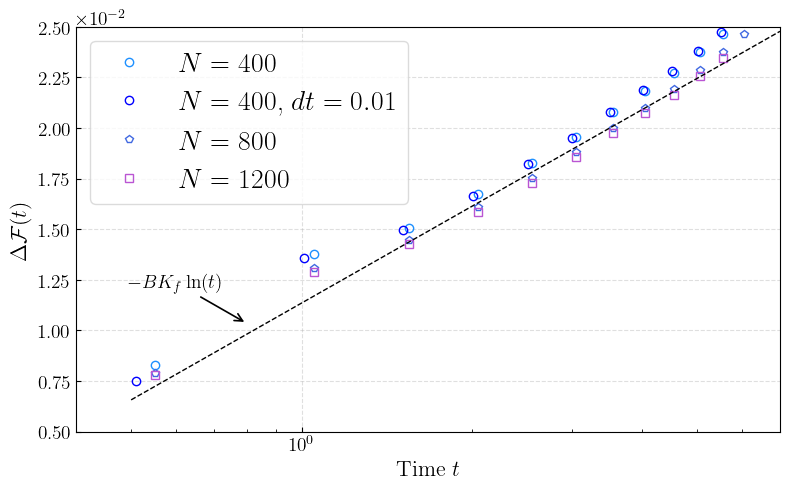

In [43]:
figure_2_paper()

 Time  F_exact  Variance  abs_diff
 0.00  0.66271  0.662711  0.000001
 0.05  0.66271  0.662712  0.000002
 0.10  0.66271  0.662712  0.000002
 0.15  0.66271  0.662712  0.000002
 0.20  0.66271  0.662712  0.000002
 0.25  0.66271  0.662712  0.000002
 0.30  0.66271  0.662712  0.000002
 0.35  0.66271  0.662712  0.000002
 0.40  0.66271  0.662713  0.000003
 0.45  0.66271  0.662713  0.000003
 0.50  0.66271  0.662713  0.000003
 0.55  0.66271  0.662713  0.000003
 0.60  0.66271  0.662713  0.000003
 0.65  0.66271  0.662713  0.000003
 0.70  0.66271  0.662713  0.000003
 0.75  0.66271  0.662713  0.000003
 0.80  0.66271  0.662713  0.000003
 0.85  0.66271  0.662713  0.000004
 0.90  0.66271  0.662714  0.000004
 0.95  0.66271  0.662714  0.000004
 1.00  0.66271  0.662714  0.000004
 1.05  0.66271  0.662714  0.000004
 1.10  0.66271  0.662714  0.000004
 1.15  0.66271  0.662714  0.000004
 1.20  0.66271  0.662714  0.000004
 1.25  0.66271  0.662714  0.000004
 1.30  0.66271  0.662714  0.000004
 1.35  0.66271  0.66

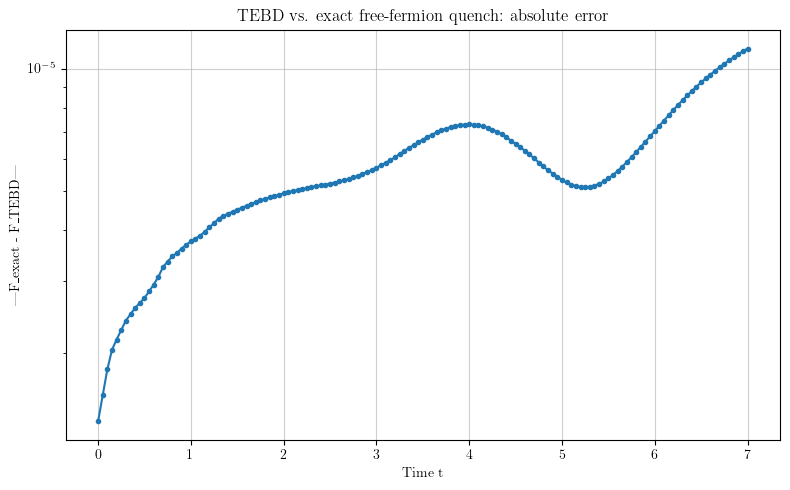

In [5]:
df_exact = pd.read_csv(data_quench_dir / "quench_LL_to_LL_NNN_ED_no_V.csv")
df_tebd  = pd.read_csv(data_quench_dir/ "quench_from_LL_to_LL_NNN_coupling_decrease_V_DV02_sites400_time7.0_bonddim1600_cutoff1.0e-10_central_subsystem_l80_testing_noV.csv")   # Time, Variance columns

# Align on time grid (should match exactly if dt is the same)
merged = pd.merge(df_exact, df_tebd, on="Time", suffixes=("_exact", "_tebd"))
merged["abs_diff"] = np.abs(merged["F_exact"] - merged["Variance"])

print(merged[["Time", "F_exact", "Variance", "abs_diff"]].to_string(index=False))
print(f"\nMax abs diff: {merged['abs_diff'].max():.2e}")
print(f"Mean abs diff: {merged['abs_diff'].mean():.2e}")

plt.figure(figsize=(8,5))
plt.semilogy(merged["Time"], merged["abs_diff"], marker='o', markersize=3)
plt.xlabel("Time t")
plt.ylabel("|F_exact - F_TEBD|")
plt.title("TEBD vs. exact free-fermion quench: absolute error")
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()
plt.show()

0.8145731472119673
0.8614293939143047
Simple ansatz (m*ln(t)+C), full range [0.1,7.0]:
  m = 0.005817  (theory: 0.004884, ratio: 1.1909)
  RSS = 2.841e-05, AIC = -2137.06
------------------------------------------------------------
Extended ansatz (m*ln(t)+C+D*t^-alpha), full range [0.1,7.0]:
  m     = 0.005933 +/- 0.000074  (theory: 0.004884, ratio: 1.2147)
  C     = 0.011415 +/- 0.000104
  D     = 0.000019 +/- 0.000046
  alpha = 2.0000 +/- 1.0430
  RSS = 2.533e-05, AIC = -2148.99
Extended model favored (ΔAIC = 11.94); correction term meaningfully improves the fit.


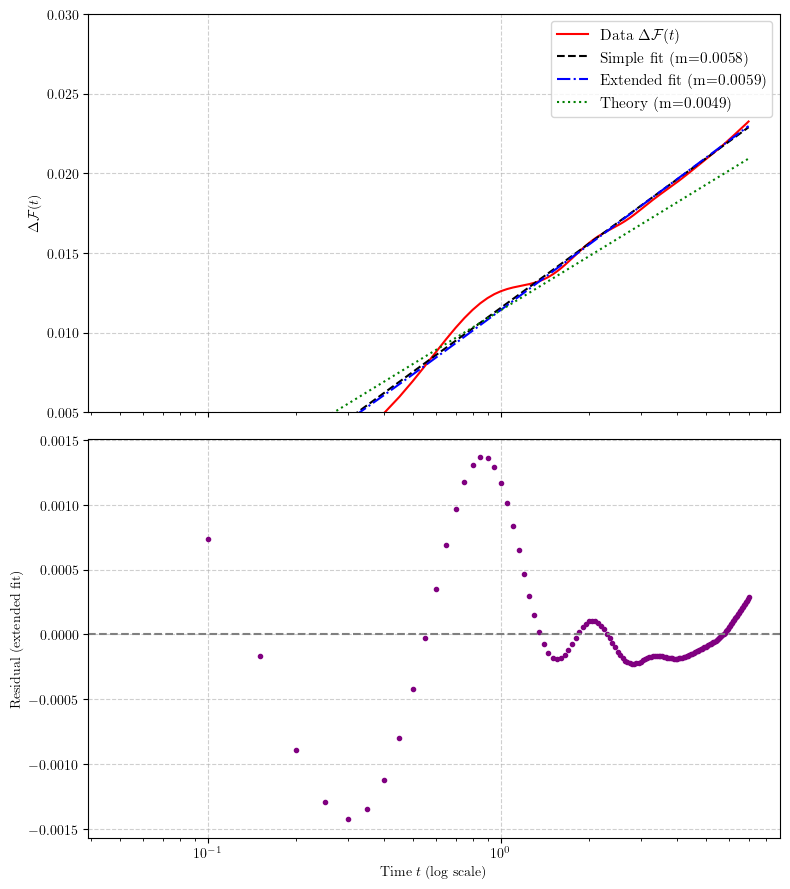

In [4]:
def extended_ansatz(t, m, C, D, alpha):
    """ΔF(t) = m*ln(t) + C + D*t^(-alpha)"""
    return m * np.log(t) + C + D * np.power(t, -alpha)

def simple_ansatz(t, m, C):
    """ΔF(t) = m*ln(t) + C  (pure leading-log, no correction)"""
    return m * np.log(t) + C


def fit_extended_ansatz(times, Fluctuations, m_theory, t_min=1.5, t_max=7.0):
    mask = (times >= t_min) & (times <= t_max)
    t_fit = times[mask]
    F_fit = Fluctuations[mask]

    # --- Simple (leading-log only) fit over the full range, for comparison ---
    p0_simple = [m_theory, 0.0]
    popt_simple, pcov_simple = curve_fit(simple_ansatz, t_fit, F_fit, p0=p0_simple)
    resid_simple = F_fit - simple_ansatz(t_fit, *popt_simple)
    rss_simple = np.sum(resid_simple**2)

    # --- Extended fit: leading-log + power-law correction ---
    # Initial guesses: m near theory, C near 0, D small, alpha ~ 1 (guess)
    p0_ext = [m_theory, 0.0, 0.01, 1.0]
    bounds_ext = ([-np.inf, -np.inf, -np.inf, 0.1], [np.inf, np.inf, np.inf, 2.0])
    popt_ext, pcov_ext = curve_fit(extended_ansatz, t_fit, F_fit, p0=p0_ext,
                                    bounds=bounds_ext, maxfev=20000)
    m_fit, C_fit, D_fit, alpha_fit = popt_ext
    perr_ext = np.sqrt(np.diag(pcov_ext))
    resid_ext = F_fit - extended_ansatz(t_fit, *popt_ext)
    rss_ext = np.sum(resid_ext**2)

    n = len(t_fit)
    k_simple, k_ext = 2, 4
    aic_simple = n * np.log(rss_simple / n) + 2 * k_simple
    aic_ext = n * np.log(rss_ext / n) + 2 * k_ext

    print("=" * 60)
    print(f"Simple ansatz (m*ln(t)+C), full range [{t_min},{t_max}]:")
    print(f"  m = {popt_simple[0]:.6f}  (theory: {m_theory:.6f}, "
          f"ratio: {popt_simple[0]/m_theory:.4f})")
    print(f"  RSS = {rss_simple:.3e}, AIC = {aic_simple:.2f}")
    print("-" * 60)
    print(f"Extended ansatz (m*ln(t)+C+D*t^-alpha), full range [{t_min},{t_max}]:")
    print(f"  m     = {m_fit:.6f} +/- {perr_ext[0]:.6f}  "
          f"(theory: {m_theory:.6f}, ratio: {m_fit/m_theory:.4f})")
    print(f"  C     = {C_fit:.6f} +/- {perr_ext[1]:.6f}")
    print(f"  D     = {D_fit:.6f} +/- {perr_ext[2]:.6f}")
    print(f"  alpha = {alpha_fit:.4f} +/- {perr_ext[3]:.4f}")
    print(f"  RSS = {rss_ext:.3e}, AIC = {aic_ext:.2f}")
    print("=" * 60)
    if aic_ext < aic_simple:
        print(f"Extended model favored (ΔAIC = {aic_simple-aic_ext:.2f}); "
              f"correction term meaningfully improves the fit.")
    else:
        print(f"Simple model favored or comparable (ΔAIC = {aic_simple-aic_ext:.2f}); "
              f"be cautious about over-interpreting the extended fit.")

    return dict(popt_simple=popt_simple, popt_ext=popt_ext, perr_ext=perr_ext,
                t_fit=t_fit, F_fit=F_fit, rss_simple=rss_simple, rss_ext=rss_ext,
                aic_simple=aic_simple, aic_ext=aic_ext)


def plot_extended_fit(times, Fluctuations, fit_result, m_theory):
    t_line = np.linspace(times.min(), times.max(), 300)
    simple_curve = simple_ansatz(t_line, *fit_result['popt_simple'])
    ext_curve = extended_ansatz(t_line, *fit_result['popt_ext'])
    theory_line = m_theory * np.log(t_line) + fit_result['popt_ext'][1]  # align intercept

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), sharex=True)

    ax1.semilogx(times, Fluctuations, color='red', label=r"Data $\Delta\mathcal{F}(t)$")
    ax1.semilogx(t_line, simple_curve, 'k--', label=f"Simple fit (m={fit_result['popt_simple'][0]:.4f})")
    ax1.semilogx(t_line, ext_curve, 'b-.', label=f"Extended fit (m={fit_result['popt_ext'][0]:.4f})")
    ax1.semilogx(t_line, theory_line, 'g:', label=f"Theory (m={m_theory:.4f})")
    ax1.set_ylabel(r"$\Delta\mathcal{F}(t)$")
    ax1.legend(fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.6)
    #ax1.set_xlim(1.0, 7.0)
    ax1.set_ylim(0.005 , 0.03)
    # Residuals of the extended fit -- should look like noise, not structure
    ax2.semilogx(fit_result['t_fit'],
                 fit_result['F_fit'] - extended_ansatz(fit_result['t_fit'], *fit_result['popt_ext']),
                 'o', color='purple', markersize=3)
    ax2.axhline(0, color='gray', linestyle='--')
    ax2.set_xlabel("Time $t$ (log scale)")
    ax2.set_ylabel("Residual (extended fit)")
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


# --- Usage, dropping into your existing script ---
# times, Fluctuations already = ΔF(t), t=0 point dropped, as in your plotting function
df = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_sites1200_time7.0_bonddim1800_cutoff1.0e-10_centered_subsystem_l80_new.csv")
times = df["Time"].values
Fluctuations = df["Variance"].values

Fluctuations = Fluctuations - Fluctuations[0]  
Fluctuations = Fluctuations[1:]
times = times[1:]

# --- Param Bethe Ansatz---
V_i = 0.7
V_f = 0.5
mu_i = np.arccos(V_i / 2)
mu_f = np.arccos(V_f / 2)

K_i = np.pi / (2 * (np.pi - mu_i))
K_f = np.pi / (2 * (np.pi - mu_f))

print(K_i)
print(K_f)

B_param = 0.5 * (K_i**2 - K_f**2) / (K_i * K_f)
m_theory = - B_param * K_f / ( np.pi**2) 

fit_result = fit_extended_ansatz(times, Fluctuations, m_theory, t_min=0.1, t_max=7.0)
plot_extended_fit(times, Fluctuations, fit_result, m_theory)

In [ ]:
def full_pretime_ansatz(t, BKf, alpha, uf, l):
    term1 = np.log((alpha**2 + (l - 2*uf*t)**2) / (alpha**2 + (2*uf*t)**2))
    term2 = np.log((alpha**2 + (l + 2*uf*t)**2) / (alpha**2 + (2*uf*t)**2))
    const = np.log((alpha**2 + l**2) / alpha**2)
    return (BKf/4)*(term1 + term2) - (BKf/2)*const

l_fixed = 80.0  # known exactly, by construction

def model(t, BKf, alpha, uf):
    return full_pretime_ansatz(t, BKf, alpha, uf, l_fixed) / np.pi**2

from scipy.optimize import curve_fit

BKf_guess = B_param * K_f  # from your equilibrium-extracted K_i, K_f
uf_guess = 2.4             # rough order-of-magnitude starting point, see below

popt, pcov = curve_fit(model, times, Fluctuations,
                        p0=[BKf_guess, 1.0, uf_guess],
                        bounds=([0, 0.01, 0.1], [np.inf, 10, 10]))
BKf_fit, alpha_fit, uf_fit = popt
perr = np.sqrt(np.diag(pcov))
print(f"Fitted B*Kf = {BKf_fit:.6f} +/- {perr[0]:.6f} (theory: {BKf_guess:.6f}, ratio: {BKf_fit/BKf_guess:.4f})")
print(f"Fitted alpha = {alpha_fit:.4f} +/- {perr[1]:.4f}")
print(f"Fitted u_f = {uf_fit:.4f} +/- {perr[2]:.4f}")